# Spiking Neural Network for Event-Based Regression

## Overview
This notebook implements a Spiking Neural Network (SNN) for continuous angle regression from event camera data. The model processes event streams from a rotating bar captured by a DAVIS346 event camera and predicts the angular position in real-time.

### Key Features
- **Multiple architectures**: Supports Plain, Spiking ResNet, and SEW (Spiking Element-Wise) blocks
- **Flexible normalization**: Batch Normalization, RMS Normalization, or learnable scaling
- **TBPTT training**: Truncated Backpropagation Through Time for efficient temporal learning

### Requirements
- GPU with CUDA support (recommended)
- Event camera data in AEDAT4 format
- Corresponding encoder measurements (CSV)

### Citation
If you use this code in your research, please cite our paper:
```
#TODO Citation 
```

## Library Instalation

In [1]:
!pip install pandas dv_processing tonic spikingjelly wandb aedat opencv-contrib-python

## Library Imports

In [2]:
# Event camera data processing libraries
import dv_processing as dv  
import numpy as np  
import cv2 as cv 
import torch.nn.functional as F  
import pandas as pd  
from scipy.interpolate import interp1d 

# Event camera data transformation library
import tonic 
from tonic import transforms, MemoryCachedDataset 

# PyTorch deep learning framework
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch import Tensor
from torch.nn.parameter import Parameter

# SpikingJelly: SNN framework for PyTorch
from spikingjelly.activation_based import neuron, surrogate, functional

# Progress tracking
from tqdm import tqdm

# Experiment tracking and logging
import wandb

# Plotting libraries
import matplotlib as mpl
import matplotlib.pyplot as plt

# Random seed control
import random

# File system operations
import os
import json
from pathlib import Path

c:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\snn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================================
# Reproducibility: Set random seeds for all libraries
# ============================================================================

SEED = 42

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

## Visualization Functions

In [ ]:
def visualize_sequence_from_trainloader(trainloader, n_sequences=5, playback_fps=10, scale=1):
    """Visualize temporal sequences from the training dataloader."""

    for seq_idx, (frames_batch, labels_batch) in enumerate(trainloader):
        if seq_idx >= n_sequences:
            break

        # frames_batch: [T, B, C, H, W]
        # labels_batch: [T, B, 2]
        T, B, C, H, W = frames_batch.shape

        print(f"\n=== Sequence {seq_idx+1}/{n_sequences} ===")
        print(f"Batch shape: {frames_batch.shape}, Labels shape: {labels_batch.shape}")

        # Visualize only the first element of the batch
        batch_item = 0

        for t in range(T):
            # frame: [C, H, W] where C=2 (ON/OFF polarities)
            frame = frames_batch[t, batch_item].cpu().numpy()
            target = labels_batch[t, batch_item].cpu().numpy()
            angle = target[0]
            position = target[1]

            # Create RGB visualization (white background)
            events_img = np.ones((H, W, 3), dtype=np.uint8) * 255

            # ON events in dark blue
            on_events = frame[0] > 0
            events_img[on_events] = [0, 0, 200]

            # OFF events in dark red
            off_events = frame[1] > 0
            events_img[off_events] = [200, 0, 0]

            # Scale image
            events_resized = cv.resize(events_img, (W * scale, H * scale), interpolation=cv.INTER_NEAREST)

            # Overlay text information
            info_text = [
                f"Seq: {seq_idx+1}/{n_sequences}  Time: {t+1}/{T}",
                f"Target angle: {np.rad2deg(angle):.2f} deg",
                f"Target {POSITION_NAME}: {position:.2f} {POSITION_UNIT}",
                f"Batch item: {batch_item+1}/{B}"
            ]

            y_offset = 30
            for text in info_text:
                cv.putText(events_resized, text, (10, y_offset), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
                y_offset += 25

            cv.imshow("Trainloader Sequence Visualization", events_resized)

            key = cv.waitKey(int(1000 / playback_fps))
            if key == 27:  # ESC key to exit
                cv.destroyAllWindows()
                return
            elif key == ord('n'):  # 'n' key to skip to next sequence
                break

    cv.destroyAllWindows()
    print("\nVisualization completed!")


# ============================================================================
# Normalization and Denormalization Functions
# ============================================================================
ANGLE_INDEX = 0
POSITION_INDEX = 1
POSITION_MIN = None
POSITION_MAX = None
POSITION_NAME = "x"
POSITION_UNIT = "mm"


def normalize_targets(targets):
    """
    Normalize [theta, position] targets to [0, 1].

    Expected shapes:
        [T, B, 2], [B, 2], or [N, 2]
    """
    if POSITION_MIN is None or POSITION_MAX is None:
        raise ValueError("Set POSITION_MIN and POSITION_MAX before normalizing targets.")

    position_span = POSITION_MAX - POSITION_MIN
    if position_span <= 0:
        raise ValueError("POSITION_MAX must be greater than POSITION_MIN.")

    targets = targets.clone()
    targets[..., ANGLE_INDEX] = (targets[..., ANGLE_INDEX] + 1.1*0.4) / (1.1*1.2 + 1.1*0.4)
    targets[..., POSITION_INDEX] = (targets[..., POSITION_INDEX] + 1.1*25000) / (1.1*(15000 + 25000))
    return targets


def denormalize_targets(normalized_targets):
    """
    Convert normalized [theta, position] targets back to [degrees, position].

    Expected shapes:
        [T, B, 2], [B, 2], or [N, 2]
    """
    if POSITION_MIN is None or POSITION_MAX is None:
        raise ValueError("Set POSITION_MIN and POSITION_MAX before denormalizing targets.")

    position_span = POSITION_MAX - POSITION_MIN
    if position_span <= 0:
        raise ValueError("POSITION_MAX must be greater than POSITION_MIN.")

    targets = np.array(normalized_targets, copy=True)
    targets[..., ANGLE_INDEX] = np.rad2deg((targets[..., ANGLE_INDEX] * (1.1*1.2 + 1.1*0.4)) - 1.1*0.4)
    targets[..., POSITION_INDEX] = targets[..., POSITION_INDEX] * (1.1*(15000 + 25000)) + 1.1*25000
    return targets

## Data Loading and Preprocessing


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

# Setting up output directories
PROJECT_ROOT = Path(r"C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True")

# Notebook modified to use local files instead of Google Drive
DATA_ROOT = Path(r"C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\Dataset")

# ---------------------------------------------------------------------------
# Pencil-balancer file configuration
# ---------------------------------------------------------------------------
EVENT_FILE = os.path.join(DATA_ROOT, "hough_cam1_cam1.aedat4")
LABEL_FILE = os.path.join(DATA_ROOT, "hough_cam1_cam1_hough.csv")

# If None, the loader tries standard CSV parsing first and then whitespace parsing.
LABEL_SEPARATOR = None

# Column mapping for the label file
TIMESTAMP_COLUMN = "timestamp_us"
ANGLE_COLUMN = "lin_m"
POSITION_COLUMN = "lin_b"

# Unit conversion controls
ANGLE_UNIT = "rad"          # Options: "rad" or "deg"
TIMESTAMP_SCALE_TO_US = 1.0  # Multiply timestamps by this factor if needed
POSITION_SCALE = 1.0         # Multiply position by this factor if needed

# Optional manual bounds for position normalization. Leave as None to infer from the file.
POSITION_MIN = None
POSITION_MAX = None
POSITION_NAME = POSITION_COLUMN
POSITION_UNIT = "mm"

In [6]:
print(EVENT_FILE)
print(os.path.exists(EVENT_FILE))
print(os.listdir(DATA_ROOT))

C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\Dataset\hough_cam1_cam1.aedat4
True
['hough_cam1_cam1.aedat4', 'hough_cam1_cam1_hough.csv']


In [7]:
# ============================================================================
# File paths for event data and ground truth labels
# ============================================================================

def load_label_file(label_path, separator=None):
    """Load a TXT or CSV label file and normalize column names."""
    label_path = Path(label_path)

    if separator is not None:
        df = pd.read_csv(label_path, sep=separator, engine="python")
    else:
        try:
            df = pd.read_csv(label_path)
        except Exception:
            df = pd.read_csv(label_path, sep=r"\s+", engine="python")

    df.columns = [str(col).strip() for col in df.columns]
    return df


# Load event data using Tonic library
events = tonic.io.read_aedat4(EVENT_FILE)

# Load ground truth measurements
df = load_label_file(LABEL_FILE, LABEL_SEPARATOR)

required_columns = [TIMESTAMP_COLUMN, ANGLE_COLUMN, POSITION_COLUMN]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(
        f"Missing required columns {missing_columns} in {LABEL_FILE}. "
        f"Available columns: {list(df.columns)}"
    )

# Convert label columns to numeric and normalize units
df[TIMESTAMP_COLUMN] = pd.to_numeric(df[TIMESTAMP_COLUMN], errors="coerce") * TIMESTAMP_SCALE_TO_US
df[ANGLE_COLUMN] = pd.to_numeric(df[ANGLE_COLUMN], errors="coerce")
df[POSITION_COLUMN] = pd.to_numeric(df[POSITION_COLUMN], errors="coerce") * POSITION_SCALE

df = df.dropna(subset=required_columns).sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)

if ANGLE_UNIT.lower() == "deg":
    df[ANGLE_COLUMN] = np.deg2rad(df[ANGLE_COLUMN])
elif ANGLE_UNIT.lower() != "rad":
    raise ValueError("ANGLE_UNIT must be either 'rad' or 'deg'.")

if POSITION_MIN is None:
    POSITION_MIN = float(df[POSITION_COLUMN].min())
if POSITION_MAX is None:
    POSITION_MAX = float(df[POSITION_COLUMN].max())
if POSITION_MAX <= POSITION_MIN:
    raise ValueError("POSITION_MAX must be greater than POSITION_MIN.")

print(f"Loaded events from: {EVENT_FILE}")
print(f"Loaded labels from: {LABEL_FILE}")
print(f"Using columns -> timestamp: {TIMESTAMP_COLUMN}, angle: {ANGLE_COLUMN}, position: {POSITION_COLUMN}")
print(f"Position range for normalization: [{POSITION_MIN:.3f}, {POSITION_MAX:.3f}] {POSITION_UNIT}")

Loaded events from: C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\Dataset\hough_cam1_cam1.aedat4
Loaded labels from: C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\Dataset\hough_cam1_cam1_hough.csv
Using columns -> timestamp: timestamp_us, angle: lin_m, position: lin_b
Position range for normalization: [-22355.567, 8927.915] mm


In [8]:
# ============================================================================
# Temporal Alignment: Synchronize events with ground-truth measurements
# ============================================================================
# Event cameras and measurement logs may not start/stop at exactly the same time.
# We find the overlapping time range to ensure valid event-label pairs.

# Determine the common time window
start_time = max(df[TIMESTAMP_COLUMN].iloc[0], events['t'][0])
end_time = min(df[TIMESTAMP_COLUMN].iloc[-1], events['t'][-1])

# Filter label data to the valid time range
mask_labels = (df[TIMESTAMP_COLUMN] >= start_time) & (df[TIMESTAMP_COLUMN] <= end_time)
df = df[mask_labels].reset_index(drop=True)

print(f"Total events before filtering: {len(events['t'])}")
print(f"Aligned label rows: {len(df)}")

Total events before filtering: 256386390
Aligned label rows: 34974


In [9]:
# ============================================================================
# Time-based Slicing: Convert continuous event stream into discrete frames
# ============================================================================
# Event cameras produce asynchronous events. We group them into fixed time windows
# to create a sequence of "frames" for the SNN.

time_window = 3000  # 3,000 microseconds = 3 milliseconds

# Slice events into time windows
events_per_frame = tonic.slicers.slice_events_by_time(
    events, 
    time_window=time_window, 
    start_time=start_time, 
    end_time=end_time
)

In [10]:
# ============================================================================
# Label interpolation and assignment
# ============================================================================
# Ground-truth measurements are sampled at discrete times, but we need a label
# for each event frame. We use linear interpolation to estimate both angle and
# position at the END of each time window.

interp_theta = interp1d(df[TIMESTAMP_COLUMN], df[ANGLE_COLUMN], fill_value="extrapolate")
interp_position = interp1d(df[TIMESTAMP_COLUMN], df[POSITION_COLUMN], fill_value="extrapolate")

# Window i ends at: start_time + (i + 1) * time_window
timestamps = start_time + np.arange(1, len(events_per_frame) + 1) * time_window

theta_vals = interp_theta(timestamps)
position_vals = interp_position(timestamps)
labels = np.stack([theta_vals, position_vals], axis=1).astype(np.float32)

print("Labels assigned successfully!")
print(f"Total grouped events: {len(events_per_frame)}")
print(f"Total labels assigned: {len(labels)}")
print(f"Label tensor shape: {labels.shape}")
print(f"Frames read: {len(events_per_frame)}")
print(f"Events read: {len(events)}")

Labels assigned successfully!
Total grouped events: 116603
Total labels assigned: 116603
Label tensor shape: (116603, 2)
Frames read: 116603
Events read: 256386390


In [11]:
START_FRAME = 300  # Skip first 300 frames
END_FRAME = -1     # Use all remaining frames

events_per_frame = events_per_frame[START_FRAME:END_FRAME]
labels = labels[START_FRAME:END_FRAME]
theta_vals = labels[:, ANGLE_INDEX]
position_vals = labels[:, POSITION_INDEX]

print(f"Frames after slicing: {len(events_per_frame)}")
print(f"Labels after slicing: {labels.shape}")

Frames after slicing: 116302
Labels after slicing: (116302, 2)


## Dataset Classes and Train/Val/Test Split

In [12]:
# ============================================================================
# Base dataset for individual frames
# ============================================================================
class RotatingBarDataset(Dataset):
    """
    Basic dataset that wraps sliced events and their corresponding labels.
    Each item returns a single time window of events and its target vector
    [theta, position].
    """
    def __init__(self, sliced_events, labels, transform=None):
        self.sliced_events = sliced_events
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.sliced_events)

    def __getitem__(self, idx):
        events = self.sliced_events[idx]
        target = self.labels[idx]

        if self.transform:
            events = self.transform(events)

        return events, target


# ============================================================================
# Fixed-length sequences for training/validation
# ============================================================================
class SequenceDataset(torch.utils.data.Dataset):
    """
    Splits a long temporal sequence into multiple fixed-length subsequences.

    Note:
        Any remaining frames that don't fit into a complete sequence are discarded.
    """
    def __init__(self, base_dataset, seq_length=5000, expected_shape=(2, 346, 260)):
        self.base_dataset = base_dataset
        self.seq_length = seq_length
        self.expected_shape = expected_shape
        self.total_length = len(base_dataset)
        self.num_sequences = self.total_length // seq_length

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_length
        end_idx = start_idx + self.seq_length

        frames = []
        labels = []

        for i in range(start_idx, end_idx):
            frame, label = self.base_dataset[i]

            if isinstance(frame, np.ndarray):
                frame = torch.from_numpy(frame)

            frame = frame.squeeze(0)  # [1, C, H, W] -> [C, H, W]

            if frame.shape != self.expected_shape:
                frame = frame.permute(0, 2, 1)  # [C, W, H] -> [C, H, W]

            frames.append(frame)
            labels.append(label)

        # frames: [T, C, H, W]
        # labels: [T, 2]
        frames = torch.stack(frames, dim=0).float()
        labels = torch.tensor(labels, dtype=torch.float32)

        return frames, labels


# ============================================================================
# Continuous sequence for testing
# ============================================================================
class ContinuousDataset(torch.utils.data.Dataset):
    """
    Loads the entire sequence without splitting, used for testing.
    """
    def __init__(self, base_dataset, expected_shape=(2, 346, 260)):
        self.base_dataset = base_dataset
        self.expected_shape = expected_shape

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        frames = []
        labels = []

        for i in range(len(self.base_dataset)):
            frame, label = self.base_dataset[i]

            if isinstance(frame, np.ndarray):
                frame = torch.from_numpy(frame)

            frame = frame.squeeze(0)

            if frame.shape != self.expected_shape:
                frame = frame.permute(0, 2, 1)

            frames.append(frame)
            labels.append(label)

        frames = torch.stack(frames, dim=0).float()      # [T, C, H, W]
        labels = torch.tensor(labels, dtype=torch.float32)  # [T, 2]

        return frames, labels

In [13]:
# ============================================================================
# Train/Validation/Test Split
# ============================================================================

input_data = events_per_frame
all_labels = labels
total_samples = len(input_data)

print(f"Total samples in dataset: {total_samples}")

# Define split ratios
test_split = 0.05
val_split = 0.07
train_split = 1.0 - test_split - val_split

# Calculate split indices (temporal order maintained)
train_end = int(train_split * total_samples)
val_end = int((train_split + val_split) * total_samples)

# Perform temporal split (NO SHUFFLE!)
train_events = input_data[:train_end]
train_labels = all_labels[:train_end]

val_events = input_data[train_end:val_end]
val_labels = all_labels[train_end:val_end]

test_events = input_data[val_end:]
test_labels = all_labels[val_end:]

# ============================================================================
# Create datasets with event-to-frame transformation
# ============================================================================
H, W = 260, 346  # DAVIS346 resolution (height, width)

frame_transform = transforms.ToFrame(
    sensor_size=(W, H, 2),
    n_event_bins=1
)

train_dataset = RotatingBarDataset(train_events, train_labels, transform=frame_transform)
val_dataset = RotatingBarDataset(val_events, val_labels, transform=frame_transform)
test_dataset = RotatingBarDataset(test_events, test_labels, transform=frame_transform)

print(f"Train dataset size: {len(train_dataset)} samples ({train_split*100:.1f}%)")
print(f"Val dataset size:   {len(val_dataset)} samples ({val_split*100:.1f}%)")
print(f"Test dataset size:  {len(test_dataset)} samples ({test_split*100:.1f}%)")

cached_trainset = MemoryCachedDataset(
    train_dataset,
    transform=lambda x: torch.from_numpy(x).float(),
)

SEQ_LENGTH = 2000
BATCH_SIZE = 4

trainset = SequenceDataset(cached_trainset, seq_length=SEQ_LENGTH, expected_shape=(2, H, W))
valset = SequenceDataset(val_dataset, seq_length=SEQ_LENGTH, expected_shape=(2, H, W))
testset = ContinuousDataset(test_dataset, expected_shape=(2, H, W))


def collate_time_first(batch):
    """
    Arrange data as [T, B, ...] instead of [B, T, ...].

    Returns:
        frames: [T, B, C, H, W]
        labels: [T, B, 2]
    """
    frames, labels = zip(*batch)
    frames = torch.stack(frames, dim=1)
    labels = torch.stack(labels, dim=1)
    return frames, labels


trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_time_first,
    shuffle=True
)

valloader = DataLoader(
    valset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_time_first,
    shuffle=False
)

testloader = DataLoader(
    testset,
    batch_size=1,
    collate_fn=collate_time_first,
    shuffle=False
)

print("\nDataLoaders created successfully!")

Total samples in dataset: 116302
Train dataset size: 102345 samples (88.0%)
Val dataset size:   8141 samples (7.0%)
Test dataset size:  5816 samples (5.0%)

DataLoaders created successfully!


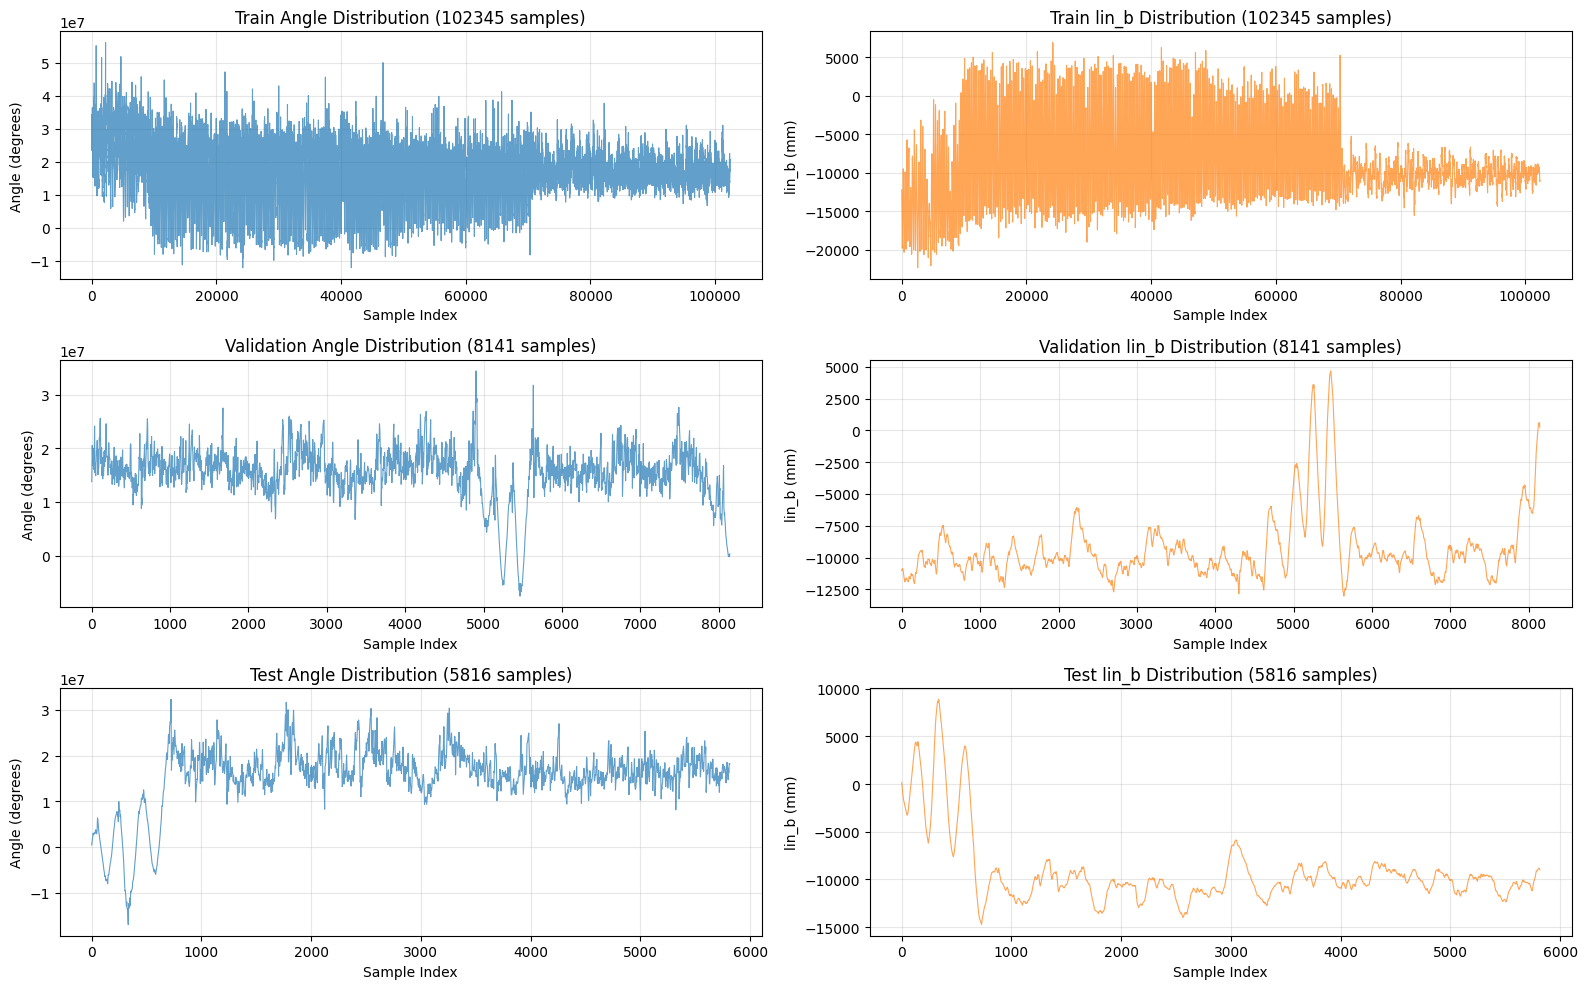


Data ranges:
Train angle range: [-12065446.00 deg, 56161784.00 deg]
Train lin_b range: [-22341.12, 6920.44] mm
Val angle range:   [-7542483.00 deg, 34393864.00 deg]
Val lin_b range:   [-13039.88, 4687.63] mm
Test angle range:  [-16894554.00 deg, 32313582.00 deg]
Test lin_b range:  [-14726.65, 8890.83] mm


In [14]:
# Verify train/val/test split distribution for both targets

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=False)

datasets_for_plot = [
    ("Train", train_labels),
    ("Validation", val_labels),
    ("Test", test_labels),
]

for row_idx, (split_name, split_labels) in enumerate(datasets_for_plot):
    angle_deg = np.rad2deg(split_labels[:, ANGLE_INDEX])
    position_vals = split_labels[:, POSITION_INDEX]

    axes[row_idx, 0].plot(angle_deg, linewidth=0.8, alpha=0.7)
    axes[row_idx, 0].set_title(f"{split_name} Angle Distribution ({len(split_labels)} samples)")
    axes[row_idx, 0].set_xlabel("Sample Index")
    axes[row_idx, 0].set_ylabel("Angle (degrees)")
    axes[row_idx, 0].grid(True, alpha=0.3)

    axes[row_idx, 1].plot(position_vals, linewidth=0.8, alpha=0.7, color="tab:orange")
    axes[row_idx, 1].set_title(f"{split_name} {POSITION_NAME} Distribution ({len(split_labels)} samples)")
    axes[row_idx, 1].set_xlabel("Sample Index")
    axes[row_idx, 1].set_ylabel(f"{POSITION_NAME} ({POSITION_UNIT})")
    axes[row_idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nData ranges:")
print(f"Train angle range: [{np.rad2deg(train_labels[:, ANGLE_INDEX].min()):.2f} deg, {np.rad2deg(train_labels[:, ANGLE_INDEX].max()):.2f} deg]")
print(f"Train {POSITION_NAME} range: [{train_labels[:, POSITION_INDEX].min():.2f}, {train_labels[:, POSITION_INDEX].max():.2f}] {POSITION_UNIT}")
print(f"Val angle range:   [{np.rad2deg(val_labels[:, ANGLE_INDEX].min()):.2f} deg, {np.rad2deg(val_labels[:, ANGLE_INDEX].max()):.2f} deg]")
print(f"Val {POSITION_NAME} range:   [{val_labels[:, POSITION_INDEX].min():.2f}, {val_labels[:, POSITION_INDEX].max():.2f}] {POSITION_UNIT}")
print(f"Test angle range:  [{np.rad2deg(test_labels[:, ANGLE_INDEX].min()):.2f} deg, {np.rad2deg(test_labels[:, ANGLE_INDEX].max()):.2f} deg]")
print(f"Test {POSITION_NAME} range:  [{test_labels[:, POSITION_INDEX].min():.2f}, {test_labels[:, POSITION_INDEX].max():.2f}] {POSITION_UNIT}")

In [15]:
# Visualize 5 sequences from trainloader, playing at 10 fps
# visualize_sequence_from_trainloader(trainloader, n_sequences=5, playback_fps=2, scale=1)

## Defining Network

### Normalization Layers

This section implements three normalization strategies for SNNs:

1. **Batch Normalization (BN)**: Standard BatchNorm2d
2. **RMS Normalization (RMS)**: Root Mean Square normalization
3. **Multiply (MUL)**: Simple learnable scaling

These are crucial for SNNs because:
- Neurons only spike when input exceeds threshold
- Without normalization, activations may be too small â†’ no spikes â†’ vanishing gradient
- Proper scaling enables spike propagation through deep networks

In [16]:
# ============================================================================
# RMS Normalization
# ============================================================================
class RMSNorm2d(nn.Module):
    """
    Root Mean Square Normalization for 2D feature maps.
    
    Unlike BatchNorm, RMSNorm:
    - Does not center the data (no mean subtraction)
    - Only normalizes by the RMS (scale only)
    
    Formula: x_norm = x / sqrt(mean(x^2) + eps)
    """
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine

        if self.affine:
            # Learnable per-channel scaling parameter
            self.weight = nn.Parameter(torch.ones(1, num_features, 1, 1))
        else:
            self.register_parameter('weight', None)

    def forward(self, x):
        # x: [B, C, H, W]
        # Compute mean squared value over spatial dimensions (H, W)
        ms = x.pow(2).mean(dim=(2, 3), keepdim=True)  # [B, C, 1, 1]
        
        # Compute RMS
        rms = torch.sqrt(ms + self.eps)

        # Normalize
        x_norm = x / rms

        # Apply learnable scaling if enabled
        if self.weight is not None:
            return x_norm * self.weight
        return x_norm


# ============================================================================
# Simple Scaling (Multiply)
# ============================================================================
class MultiplyBy(nn.Module):
    """
    Simple multiplication by a learnable or fixed scalar.
    
    From: https://github.com/urancon/StereoSpike/blob/main/network/blocks.py
    """
    def __init__(self, weight: float = 5., learnable: bool = True) -> None:
        super(MultiplyBy, self).__init__()

        if learnable:
            # Learnable parameter
            self.weight = Parameter(Tensor([weight]))
        else:
            # Fixed value
            self.weight = weight

    def forward(self, input: Tensor) -> Tensor:
        return torch.mul(input, self.weight)


# ============================================================================
# Normalization Factory Function
# ============================================================================
def get_norm_layer(norm_type: str, num_features: int, learnable: bool = True, eps: float = 1e-5, init_scale: float = 5.0
):
    """
    Factory function to create normalization layers.
    """
    if norm_type == "BN":
        # Standard BatchNorm2d
        return nn.BatchNorm2d(num_features, affine=learnable, eps=eps)

    elif norm_type == "RMS":
        # RMS Normalization
        return RMSNorm2d(num_features, eps=eps, affine=learnable)

    elif norm_type == "MUL":
        # Simple scaling
        return MultiplyBy(init_scale, learnable=learnable)

    elif norm_type is None:
        # No normalization
        return nn.Identity()

    else:
        raise ValueError(f"Unknown normalization type: {norm_type}")

### Building Blocks

This section defines the fundamental building blocks for the SNN:

1. **PlainBlock**: Sequential conv-LIF layers without residual connections
2. **SpikingBlock**: Spiking ResNet block with residual connections  
3. **SEWBlock**: Spiking Element-Wise block with flexible connection functions

Adapted from: https://github.com/fangwei123456/Spike-Element-Wise-ResNet

In [17]:
# ============================================================================
# Convolution Helpers
# ============================================================================
def conv3x3(in_ch, out_ch, stride=1, norm_type="BN", learnable=True, init_scale=5.0):
    """
    3x3 convolution with normalization.
    """
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
        get_norm_layer(norm_type, out_ch, learnable=learnable, init_scale=init_scale)
    )


def conv1x1(in_ch, out_ch, stride=1, norm_type="BN", learnable=True, init_scale=5.0):
    """
    1x1 convolution with normalization.
    """
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
        get_norm_layer(norm_type, out_ch, learnable=learnable, init_scale=init_scale)
    )


# ============================================================================
# Plain Block (No Residual Connection)
# ============================================================================
class PlainBlock(nn.Module):
    """
    Plain convolutional block without residual connections.
    
    Architecture:
        Conv3x3 â†’ Norm â†’ LIF â†’ Conv3x3 â†’ Norm â†’ LIF
    """
    def __init__(self, in_channels, mid_channels, tau=2.0, Plif=False, v_reset=0.0,
                 surrogate_function=surrogate.ATan(), stride1=1, stride2=1,
                 norm_type="BN", learnable_norm=True, init_scale=5.0):
        super(PlainBlock, self).__init__()

        self.conv = nn.Sequential(
            # First conv-norm-LIF
            conv3x3(in_channels, mid_channels, stride=stride1, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale),
            neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
            if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True),

            # Second conv-norm-LIF
            conv3x3(mid_channels, in_channels, stride=stride2, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale),
            neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
            if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
        )

    def forward(self, x: torch.Tensor):
        return self.conv(x)


# ============================================================================
# Spiking ResNet Block
# ============================================================================
class SpikingBlock(nn.Module):
    """
    Spiking ResNet block with residual connection.
    
    Architecture:
        x â†’ Conv3x3 â†’ Norm â†’ LIF â†’ Conv3x3 â†’ Norm â†’ (+) â†’ LIF â†’ out
        â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€ downsample â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜
    """
    def __init__(self, in_channels, mid_channels, tau=2.0, Plif=False, v_reset=0.0,
                 surrogate_function=surrogate.ATan(), stride1=1, stride2=1,
                 norm_type="BN", learnable_norm=True, init_scale=5.0):
        super(SpikingBlock, self).__init__()

        # Main path
        self.conv = nn.Sequential(
            conv3x3(in_channels, mid_channels, stride=stride1, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale),
            neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
            if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True),

            nn.Conv2d(mid_channels, in_channels, kernel_size=3, padding=1, stride=stride2, bias=False),
            get_norm_layer(norm_type=norm_type, num_features=in_channels, learnable=learnable_norm, init_scale=init_scale)
        )

        # Output LIF (after addition)
        self.sn = neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True) \
                  if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)

        # Shortcut connection (downsample if needed)
        if stride1 == 2:
            self.downsample = conv1x1(in_channels, in_channels, stride=2, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale)
        else:
            self.downsample = nn.Identity()

    def forward(self, x: torch.Tensor):
        # Residual connection: x + conv(x)
        return self.sn(self.downsample(x) + self.conv(x))


# ============================================================================
# SEW (Spiking Element-Wise) Block
# ============================================================================
class SEWBlock(nn.Module):
    """
    Spiking Element-Wise residual block with flexible connection functions.
    
    Architecture:
        x â†’ Conv3x3 â†’ Norm â†’ LIF â†’ Conv3x3 â†’ Norm â†’ LIF â†’ (+) â†’ out
        â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€ downsample â†’ LIF â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜
    """
    def __init__(self, in_channels, mid_channels, tau=2.0, Plif=False, v_reset=0.0,
                 surrogate_function=surrogate.ATan(), stride1=1, stride2=1,
                 connect_f="ADD", norm_type="BN", learnable_norm=True, init_scale=5.0):
        super().__init__()

        self.connect_f = connect_f

        # First conv-norm-LIF
        self.conv1 = conv3x3(in_channels, mid_channels, stride=stride1, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale)
        self.lif1 = neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True) \
                    if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)

        # Second conv-norm-LIF
        self.conv2 = conv3x3(mid_channels, in_channels, stride=stride2, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale)
        self.lif2 = neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True) \
                    if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)

        # Shortcut (with LIF)
        if stride1 == 2:
            self.downsample = nn.Sequential(
                conv1x1(in_channels, in_channels, stride=2, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale),
                neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
                if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
            )
        else:
            self.downsample = nn.Identity()

    def forward(self, x):
        # Shortcut path (produces spikes)
        identity = self.downsample(x)

        # Main path
        spk1 = self.lif1(self.conv1(x))
        spk2 = self.lif2(self.conv2(spk1))

        # Apply connection function
        if self.connect_f == "ADD":
            return spk2 + identity
        elif self.connect_f == "AND":
            return spk2 * identity 
        elif self.connect_f == "IAND":
            return identity * (1 - spk2) 
        else:
            raise NotImplementedError

### Main SNN Architecture

The `SNN_Net` class defines the complete network architecture:

In [18]:
class SNN_Net(nn.Module):
    """
    Complete Spiking Neural Network for event-based regression.

    This network processes event camera frames through a series of convolutional
    blocks followed by fully connected layers to predict both the pencil angle
    and the pencil position.

    Architecture:
        Input [B, 2, 346, 260] (ON/OFF event frames)
          -> Convolutional Blocks (with normalization + LIF neurons)
          -> Flatten
          -> FC Layer + LIF
          -> Output FC + LIF (infinite threshold for regression)
          -> Output membrane potential [B, 2]
    """
    def __init__(self, tau=2.0, final_tau=20.0, layer_list=None, hidden=256, v_reset=0.0,
                 surrogate_function=surrogate.ATan(), connect_f="ADD", Plif=False,
                 norm_type="BN", learnable_norm=True, init_scale=5.0):
        super().__init__()

        self.norm_type = norm_type

        # ====================================================================
        # Build sequential convolution pipeline
        # ====================================================================
        conv_blocks = []
        in_channels = 2  # ON/OFF event channels

        for cfg in layer_list:
            channels = cfg["channels"]
            mid_channels = cfg["mid_channels"]

            if in_channels != channels:
                if cfg["up_kernel_size"] == 3:
                    conv_blocks.append(conv3x3(in_channels, channels, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale))
                elif cfg["up_kernel_size"] == 1:
                    conv_blocks.append(conv1x1(in_channels, channels, norm_type=norm_type, learnable=learnable_norm, init_scale=init_scale))
                else:
                    raise NotImplementedError

                conv_blocks.append(
                    neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
                    if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
                )
                in_channels = channels

            for _ in range(cfg["num_blocks"]):
                if cfg["block_type"] == "sew":
                    conv_blocks.append(
                        SEWBlock(in_channels, mid_channels, tau=tau, Plif=Plif, v_reset=v_reset,
                                stride1=cfg["stride_1"], stride2=cfg["stride_2"], connect_f=connect_f,
                                norm_type=norm_type, learnable_norm=learnable_norm, init_scale=init_scale)
                    )
                elif cfg["block_type"] == "plain":
                    conv_blocks.append(
                        PlainBlock(in_channels, mid_channels, tau=tau, Plif=Plif, v_reset=v_reset,
                                  stride1=cfg["stride_1"], stride2=cfg["stride_2"],
                                  norm_type=norm_type, learnable_norm=learnable_norm, init_scale=init_scale)
                    )
                elif cfg["block_type"] == "spiking":
                    conv_blocks.append(
                        SpikingBlock(in_channels, mid_channels, tau=tau, Plif=Plif, v_reset=v_reset,
                                    stride1=cfg["stride_1"], stride2=cfg["stride_2"],
                                    norm_type=norm_type, learnable_norm=learnable_norm, init_scale=init_scale)
                    )
                else:
                    raise NotImplementedError

            if "k_pool" in cfg and cfg["k_pool"] > 1:
                conv_blocks.append(nn.MaxPool2d(kernel_size=cfg["k_pool"]))

        self.conv = nn.ModuleList(conv_blocks)

        # ====================================================================
        # Automatic computation of flattened feature dimension
        # ====================================================================
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 346, 260)
            for module in self.conv:
                dummy = module(dummy)
            flat_dim = dummy.numel()

        # ====================================================================
        # Fully Connected Layers
        # ====================================================================
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flat_dim, hidden, bias=False)
        self.lif_hidden = (
            neuron.ParametricLIFNode(init_tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
            if Plif else neuron.LIFNode(tau=tau, v_reset=v_reset, surrogate_function=surrogate_function, detach_reset=True)
        )

        # Two regression outputs: [theta, position]
        self.fc_out = nn.Linear(hidden, 2, bias=False)
        self.lif_out = neuron.LIFNode(
            tau=final_tau,
            v_threshold=float('inf'),
            surrogate_function=surrogate_function,
            detach_reset=True,
        )

    def detach(self):
        """Detach membrane potentials of all LIF neurons for TBPTT."""
        for module in self.modules():
            if isinstance(module, neuron.BaseNode):
                module.v.detach_()

    # ========================================================================
    # SPIKE ACTIVITY MONITORING
    # ========================================================================
    def _register_spike_hooks(self):
        self.spike_record = {}
        self.hooks = []

        for name, module in self.named_modules():
            if isinstance(module, neuron.BaseNode):
                hook = module.register_forward_hook(self._make_spike_hook(name))
                self.hooks.append(hook)

    def _make_spike_hook(self, name):
        def hook(module, inp, out):
            self.spike_record[name] = out.detach().clone()
        return hook

    def enable_spike_recording(self):
        self._register_spike_hooks()

    def disable_spike_recording(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
        self.spike_record = {}

    # ========================================================================
    # NORMALIZATION STATISTICS MONITORING
    # ========================================================================
    def _register_norm_hooks(self):
        self.norm_stats = {}
        self.norm_hooks = []

        if self.norm_type == "BN":
            module_type = nn.BatchNorm2d
        elif self.norm_type == "RMS":
            module_type = RMSNorm2d
        else:
            print(f"No normalization monitoring available for norm_type={self.norm_type}")
            return

        norm_counter = 0
        for name, module in self.named_modules():
            if isinstance(module, module_type):
                hook = module.register_forward_hook(
                    self._make_norm_hook(f"{self.norm_type}_{norm_counter}_{name}")
                )
                self.norm_hooks.append(hook)
                norm_counter += 1

    def _make_norm_hook(self, layer_name):
        def hook(module, inp, out):
            input_tensor = inp[0].detach()
            output_tensor = out.detach()

            B, C, H, W = input_tensor.shape
            input_flat = input_tensor.view(B, C, -1)
            output_flat = output_tensor.view(B, C, -1)

            self.norm_stats[layer_name] = {
                'input_mean_per_channel': input_flat.mean(dim=(0, 2)).cpu().numpy(),
                'input_std_per_channel': input_flat.std(dim=(0, 2)).cpu().numpy(),
                'input_min_per_channel': input_flat.min(dim=2)[0].mean(dim=0).cpu().numpy(),
                'input_max_per_channel': input_flat.max(dim=2)[0].mean(dim=0).cpu().numpy(),
                'output_mean_per_channel': output_flat.mean(dim=(0, 2)).cpu().numpy(),
                'output_std_per_channel': output_flat.std(dim=(0, 2)).cpu().numpy(),
                'output_min_per_channel': output_flat.min(dim=2)[0].mean(dim=0).cpu().numpy(),
                'output_max_per_channel': output_flat.max(dim=2)[0].mean(dim=0).cpu().numpy(),
            }
        return hook

    def enable_norm_monitoring(self):
        self._register_norm_hooks()

    def disable_norm_monitoring(self):
        for hook in self.norm_hooks:
            hook.remove()
        self.norm_hooks = []
        self.norm_stats = {}

    def get_norm_stats(self):
        return self.norm_stats

    # ========================================================================
    # FORWARD PASS
    # ========================================================================
    def forward(self, x):
        """
        Forward pass for a single timestep.

        Input:
            x: [B, 2, H, W]
        Output:
            membrane potential [B, 2] for [theta, position]
        """
        out = x

        for module in self.conv:
            out = module(out)

        out = self.flatten(out)
        out = self.fc1(out)
        out = self.lif_hidden(out)
        out = self.fc_out(out)
        _ = self.lif_out(out)
        return self.lif_out.v

### Layer Configurations

This section defines three different layer configurations for experimentation.

In [19]:
# ============================================================================
# SEW (Spiking Element-Wise) Architecture
# ============================================================================
layer_list_sew = [
    # STEM: Early aggressive downsampling to reduce computational cost
    {
        'channels': 16,          # Output channels
        'up_kernel_size': 3,     # 3x3 conv for initial feature extraction
        'mid_channels': 16,      # Intermediate channels in block
        'num_blocks': 1,         # Single block
        'block_type': 'sew',     # SEW block type
        'k_pool': 2,             # 2x2 MaxPool â†’ /2 spatial reduction
        'stride_1': 2,           # First conv: stride 2 â†’ /2 reduction
        'stride_2': 1            # Second conv: stride 1 â†’ preserve size
    },

    # LAYER 1: Maintain resolution, basic feature extraction
    {
        'channels': 16, 
        'up_kernel_size': 1,     # 1x1 conv (efficient channel adjustment)
        'mid_channels': 16,
        'num_blocks': 1,
        'block_type': 'sew',
        'k_pool': 1,             # No pooling
        'stride_1': 1,
        'stride_2': 1
    },

    # LAYER 2: Increase capacity + downsample
    {
        'channels': 24, 
        'up_kernel_size': 1,
        'mid_channels': 24,
        'num_blocks': 1,
        'block_type': 'sew',
        'k_pool': 2,             # /2 spatial reduction
        'stride_1': 1,
        'stride_2': 1
    },

    # LAYER 3: Further increase capacity + downsample
    {
        'channels': 32, 
        'up_kernel_size': 1,
        'mid_channels': 32,
        'num_blocks': 1,
        'block_type': 'sew',
        'k_pool': 2,             # /2 spatial reduction
        'stride_1': 1,
        'stride_2': 1
    },
]


# ============================================================================
# Plain Architecture (No Residual Connections)
# ============================================================================
layer_list_plain = [
    # STEM: Early downsampling
    {
        'channels': 16, 
        'up_kernel_size': 3,
        'mid_channels': 16,
        'num_blocks': 1,
        'block_type': 'plain',
        'k_pool': 2,
        'stride_1': 2,
        'stride_2': 1
    },

    # LAYER 1: Minimal expansion
    {
        'channels': 16, 
        'up_kernel_size': 1,
        'mid_channels': 16,
        'num_blocks': 1,
        'block_type': 'plain',
        'k_pool': 1,
        'stride_1': 1,
        'stride_2': 1
    },

    # LAYER 2: Modest capacity increase
    {
        'channels': 24, 
        'up_kernel_size': 1,
        'mid_channels': 24,
        'num_blocks': 1,
        'block_type': 'plain',
        'k_pool': 2,
        'stride_1': 1,
        'stride_2': 1
    },

    # LAYER 3: Final expansion
    {
        'channels': 32, 
        'up_kernel_size': 1,
        'mid_channels': 32,
        'num_blocks': 1,
        'block_type': 'plain',
        'k_pool': 2,
        'stride_1': 1,
        'stride_2': 1
    },
]


# ============================================================================
# Spiking ResNet Architecture
# ============================================================================
layer_list_spiking = [
    # STEM: Strong early downsampling
    {
        'channels': 16, 
        'up_kernel_size': 3,
        'mid_channels': 16,
        'num_blocks': 1,
        'block_type': 'spiking',
        'k_pool': 2,
        'stride_1': 2,
        'stride_2': 1
    },

    # LAYER 1: Basic blocks
    {
        'channels': 16, 
        'up_kernel_size': 1,
        'mid_channels': 16,
        'num_blocks': 1,
        'block_type': 'spiking',
        'k_pool': 1,
        'stride_1': 1,
        'stride_2': 1
    },

    # LAYER 2: Gentle downsampling
    {
        'channels': 24, 
        'up_kernel_size': 1,
        'mid_channels': 24,
        'num_blocks': 1,
        'block_type': 'spiking',
        'k_pool': 2,
        'stride_1': 1,
        'stride_2': 1
    },

    # LAYER 3: Final expansion
    {
        'channels': 32, 
        'up_kernel_size': 1,
        'mid_channels': 32,
        'num_blocks': 1,
        'block_type': 'spiking',
        'k_pool': 2,
        'stride_1': 1,
        'stride_2': 1
    },
]

### Model Hyperparameters

In [20]:
# ============================================================================
# Model Hyperparameters and Configuration
# ============================================================================

# Weights & Biases logging
use_wandb = True
wandb_name = "snn-pencil-regression-colab"

# Select architecture type
block_type = 'SEW'  # Options: 'SEW', 'plain', 'spiking'

hidden = 256     # Hidden layer size

# Neuron reset type
reset_type = 'soft'  # options: 'hard' or 'soft' reset for LIF neurons

surrogate_function = surrogate.ATan()  # Gradient surrogate (arctan)
Plif = False                          # Use standard LIF (not parametric)
tau = 2.0                             # Time constant for hidden neurons
final_tau = 20.0                      # Time constant for output neuron

norm_type = 'RMS'        # Normalization type: 'BN', 'RMS', 'MUL', or None
learnable_norm = True   # Whether normalization parameters are learnable
init_scale = 5.0        # Initial scale for Multiplication layers

K = 10           # TBPTT truncation window (backprop every K timesteps)
transient = 0    # Initial timesteps to skip (warmup for recurrent states)

num_epochs = 30

early_stop_patience = 10

device = torch.device("cuda") if torch.cuda.is_available() else \
         torch.device("mps") if torch.backends.mps.is_available() else \
         torch.device("cpu")

# ============================================================================
# Model initialization
# ============================================================================
if block_type.lower() == 'sew':
    layer_list = layer_list_sew
elif block_type.lower() == 'plain':
    layer_list = layer_list_plain
elif block_type.lower() == 'spiking':
    layer_list = layer_list_spiking

if reset_type == 'hard':
    v_reset = 0.0
elif reset_type == 'soft':
    v_reset = None

model = SNN_Net(
    tau=tau,
    final_tau=final_tau,
    layer_list=layer_list,
    hidden=hidden,
    v_reset=v_reset,
    surrogate_function=surrogate_function,
    connect_f="ADD",
    Plif=Plif,
    norm_type=norm_type,
    learnable_norm=learnable_norm,
    init_scale=init_scale,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Total trainable parameters: 2,793,000


In [21]:
#model.load_state_dict(torch.load('/content/drive/MyDrive/models/model_SEW_BN/checkpoints_pendulum/best_model_weights.pth', weights_only=True))

In [22]:
model

SNN_Net(
  (conv): ModuleList(
    (0): Sequential(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): RMSNorm2d()
    )
    (1): LIFNode(
      v_threshold=1.0, v_reset=None, detach_reset=True, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): SEWBlock(
      (conv1): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): RMSNorm2d()
      )
      (lif1): LIFNode(
        v_threshold=1.0, v_reset=None, detach_reset=True, step_mode=s, backend=torch, tau=2.0
        (surrogate_function): ATan(alpha=2.0, spiking=True)
      )
      (conv2): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): RMSNorm2d()
      )
      (lif2): LIFNode(
        v_threshold=1.0, v_reset=None, detach_reset=True, step_mode=s, backend=torch, tau=2.0
        (surrogate_function): ATan

## Training Pipeline

This section implements the complete training pipeline using **Truncated Backpropagation Through Time (TBPTT)**.

### Training Configuration

In [23]:
# ============================================================================
# Training Configuration Dictionary
# ============================================================================
CONFIG = {
    # Data configuration
    "event_file": str(EVENT_FILE),
    "label_file": str(LABEL_FILE),
    "timestamp_column": TIMESTAMP_COLUMN,
    "angle_column": ANGLE_COLUMN,
    "position_column": POSITION_COLUMN,
    "position_name": POSITION_NAME,
    "position_unit": POSITION_UNIT,
    "position_min": POSITION_MIN,
    "position_max": POSITION_MAX,
    "time_window_us": time_window,

    # Model architecture
    "block_type": block_type,
    "model_name": model.__class__.__name__,
    "hidden": hidden,
    "tau": tau,
    "final_tau": final_tau,
    "reset_type": reset_type,
    "surrogate_function": surrogate_function.__class__.__name__,
    "Plif": Plif,
    "norm_type": norm_type,
    "learnable_norm": learnable_norm,
    "init_scale": init_scale,

    # TBPTT parameters
    "K": K,
    "transient": transient,
    "batch_size": BATCH_SIZE,
    "sequence_length": SEQ_LENGTH,

    # Optimizer configuration
    "optimizer": "Adam",
    "learning_rate": 5e-4,
    "weight_decay": 0.0,

    # Learning rate scheduler
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 1,
    "min_lr": 1e-6,

    # Training loop
    "num_epochs": num_epochs,
    "device": str(device),

    # Early stopping
    "early_stop_patience": early_stop_patience,
}

output_dir = PROJECT_ROOT / "models" / f"model_{CONFIG['block_type']}_{CONFIG['norm_type']}" / "checkpoints_pencil"
output_dir.mkdir(parents=True, exist_ok=True)

config_path = output_dir / "config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print(f"Configuration saved to: {config_path}")

# ============================================================================
# Initialize Weights & Biases
# ============================================================================
if use_wandb:
    run_name = (
        f"{CONFIG['block_type']}_theta+{POSITION_NAME}_"
        f"final_tau={CONFIG['final_tau']}_tau={CONFIG['tau']}_norm={CONFIG['norm_type']}_plif={CONFIG['Plif']}"
    )

    wandb.init(
        project=wandb_name,
        name=run_name,
        config=CONFIG,
        dir=str(output_dir)
    )

    wandb.watch(model, log="all", log_freq=100)
    print("W&B initialized successfully")
    print(f"Run name: {run_name}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\pcadm\_netrc.


Configuration saved to: C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\models\model_SEW_RMS\checkpoints_pencil\config.json


wandb: Currently logged in as: sgalvao (sgalvao-purdue-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B initialized successfully
Run name: SEW_theta+lin_b_final_tau=20.0_tau=2.0_norm=RMS_plif=False


### Optimizer and Learning Rate Scheduler

In [24]:
# ============================================================================
# Optimizer Setup
# ============================================================================
if CONFIG["optimizer"] == "SGD":
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        momentum=CONFIG["momentum"],
        weight_decay=CONFIG["weight_decay"]
    )
elif CONFIG["optimizer"] == "Adam":
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"]
    )
else:
    raise ValueError(f"Unknown optimizer: {CONFIG['optimizer']}")

# ============================================================================
# Loss Function
# ============================================================================
# Mean Squared Error for regression
loss_fn = torch.nn.MSELoss()

# ============================================================================
# Learning Rate Scheduler
# ============================================================================
if CONFIG["scheduler"] == "ReduceLROnPlateau":
    # Reduce LR when validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',                          
        factor=CONFIG["scheduler_factor"],  
        patience=CONFIG["scheduler_patience"],
        min_lr=CONFIG["min_lr"]              
    )
elif CONFIG["scheduler"] == "CosineAnnealing":
    # Cosine annealing schedule
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["num_epochs"]
    )
else:
    scheduler = None

print("Optimizer and scheduler configured successfully")

Optimizer and scheduler configured successfully


### Validation Function

Evaluates model performance on the validation set without gradient computation.

In [25]:
def validate(model, val_loader, device, transient=0):
    """Validation loop for [theta, position] regression."""
    model.eval()

    loss_function_mse = torch.nn.MSELoss()
    loss_function_l1 = torch.nn.L1Loss()

    val_loss_mse_total = 0.0
    val_loss_l1_total = 0.0
    val_rel_err_total = 0.0
    iter_count = 0

    with torch.no_grad():
        pbar_val = tqdm(iter(val_loader), desc="  Validation", leave=False)

        for data, targets in pbar_val:
            iter_count += 1
            data = data.to(device)                # [T, B, C, H, W]
            targets = normalize_targets(targets.to(device))  # [T, B, 2]

            num_steps = data.size(0)
            functional.reset_net(model)

            val_mem_list = []
            for step in range(num_steps):
                mem_out = model(data[step])       # [B, 2]
                val_mem_list.append(mem_out)

            batch_predictions = torch.stack(val_mem_list, dim=0)  # [T, B, 2]
            batch_predictions_eff = batch_predictions[transient:]
            targets_eff = targets[transient:]

            mse_angle = loss_function_mse(
                batch_predictions_eff[..., ANGLE_INDEX],
                targets_eff[..., ANGLE_INDEX],
            )
            mse_position = loss_function_mse(
                batch_predictions_eff[..., POSITION_INDEX],
                targets_eff[..., POSITION_INDEX],
            )
            batch_loss_mse = mse_angle + mse_position
            batch_loss_l1 = loss_function_l1(batch_predictions_eff, targets_eff)

            rel_err_angle = torch.linalg.norm(
                batch_predictions_eff[..., ANGLE_INDEX] - targets_eff[..., ANGLE_INDEX]
            ) / torch.linalg.norm(targets_eff[..., ANGLE_INDEX])
            rel_err_position = torch.linalg.norm(
                batch_predictions_eff[..., POSITION_INDEX] - targets_eff[..., POSITION_INDEX]
            ) / torch.linalg.norm(targets_eff[..., POSITION_INDEX])
            batch_rel_err = 0.5 * (rel_err_angle + rel_err_position)

            val_loss_mse_total += batch_loss_mse.item()
            val_loss_l1_total += batch_loss_l1.item()
            val_rel_err_total += batch_rel_err.item()

            pbar_val.set_postfix({
                'mse': f'{batch_loss_mse.item():.6f}',
                'l1': f'{batch_loss_l1.item():.6f}'
            })

        pbar_val.close()

    avg_val_loss_mse = val_loss_mse_total / iter_count
    avg_val_loss_l1 = val_loss_l1_total / iter_count
    avg_val_rel_err = val_rel_err_total / iter_count

    return {
        'mse': avg_val_loss_mse,
        'l1': avg_val_loss_l1,
        'rel_err': avg_val_rel_err
    }

### Main Training Loop with TBPTT

In [26]:
print(f"\n{'='*70}")
print("Starting TBPTT training")
print(f"{'='*70}")
print(f"  Total sequence length: {len(train_dataset)} timesteps")
print(f"  TBPTT window size (K): {K}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Optimizer: {CONFIG['optimizer']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Device: {device}")
print(f"{'='*70}\n")

history = {
    'train_loss': [],
    'val_loss_mse': [],
    'val_loss_l1': [],
    'val_rel_err': [],
    'learning_rate': [],
    'best_epoch': 0
}

best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0

for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n{'-'*70}")
    print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.2e}")
    print(f"{'-'*70}")

    model.train()
    epoch_loss = 0.0
    total_chunks = 0

    pbar_train = tqdm(iter(trainloader), desc="  Training", leave=True)

    for batch_idx, (data, targets) in enumerate(pbar_train):
        data = data.to(device)                         # [T, B, C, H, W]
        targets = normalize_targets(targets.to(device))  # [T, B, 2]

        num_steps = data.size(0)
        functional.reset_net(model)

        step_trunc = 0
        K_count = 0
        mem_rec_trunc = []
        batch_loss = 0.0
        batch_chunks = 0

        for step in range(num_steps):
            mem_out = model(data[step])               # [B, 2]
            mem_rec_trunc.append(mem_out)
            step_trunc += 1

            if step_trunc == K:
                pred_chunk = torch.stack(mem_rec_trunc, dim=0)  # [K, B, 2]
                start_idx = int(K_count * K)
                end_idx = int((K_count + 1) * K)
                target_slice = targets[start_idx:end_idx]       # [K, B, 2]

                loss_angle = loss_fn(pred_chunk[..., ANGLE_INDEX], target_slice[..., ANGLE_INDEX])
                loss_position = loss_fn(pred_chunk[..., POSITION_INDEX], target_slice[..., POSITION_INDEX])
                loss = loss_angle + loss_position

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                model.detach()

                if step >= transient:
                    epoch_loss += loss.item()
                    batch_loss += loss.item()
                    total_chunks += 1
                    batch_chunks += 1

                    if use_wandb:
                        wandb.log({
                            "train/chunk_loss": loss.item(),
                            "train/learning_rate": current_lr,
                            "train/epoch": epoch + 1,
                            "train/batch": batch_idx,
                        })

                K_count += 1
                step_trunc = 0
                mem_rec_trunc = []

            if (step == num_steps - 1) and (mem_rec_trunc):
                pred_chunk = torch.stack(mem_rec_trunc, dim=0)
                remaining_len = pred_chunk.size(0)
                idx_start = K_count * K
                idx_end = idx_start + remaining_len
                target_slice = targets[int(idx_start):int(idx_end)]

                loss_angle = loss_fn(pred_chunk[..., ANGLE_INDEX], target_slice[..., ANGLE_INDEX])
                loss_position = loss_fn(pred_chunk[..., POSITION_INDEX], target_slice[..., POSITION_INDEX])
                loss = loss_angle + loss_position

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                model.detach()

                if step >= transient:
                    epoch_loss += loss.item()
                    batch_loss += loss.item()
                    total_chunks += 1
                    batch_chunks += 1

                    if use_wandb:
                        wandb.log({
                            "train/chunk_loss": loss.item(),
                            "train/learning_rate": current_lr,
                            "train/epoch": epoch + 1,
                            "train/batch": batch_idx,
                        })

        avg_batch_loss = batch_loss / max(1, batch_chunks)
        pbar_train.set_postfix({'loss': f'{avg_batch_loss:.6f}'})

    pbar_train.close()

    avg_train_loss = epoch_loss / max(1, total_chunks)

    val_metrics = validate(model, valloader, device, transient)
    avg_val_loss_mse = val_metrics['mse']
    avg_val_loss_l1 = val_metrics['l1']
    avg_val_rel_err = val_metrics['rel_err']

    history['train_loss'].append(avg_train_loss)
    history['val_loss_mse'].append(avg_val_loss_mse)
    history['val_loss_l1'].append(avg_val_loss_l1)
    history['val_rel_err'].append(avg_val_rel_err)
    history['learning_rate'].append(current_lr)

    print(f"  Train Loss (MSE): {avg_train_loss:.6f}")
    print(f"  Val Loss (MSE):   {avg_val_loss_mse:.6f}")
    print(f"  Val Loss (L1):    {avg_val_loss_l1:.6f}")
    print(f"  Val Rel Error:    {avg_val_rel_err:.6f}")

    if use_wandb:
        wandb.log({
            "epoch/train_loss": avg_train_loss,
            "epoch/val_loss_mse": avg_val_loss_mse,
            "epoch/val_loss_l1": avg_val_loss_l1,
            "epoch/val_rel_err": avg_val_rel_err,
            "epoch/learning_rate": current_lr,
            "epoch/number": epoch + 1,
        })

    checkpoint_latest = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'train_loss': avg_train_loss,
        'val_loss_mse': avg_val_loss_mse,
        'val_loss_l1': avg_val_loss_l1,
        'val_rel_err': avg_val_rel_err,
        'history': history,
        'config': CONFIG,
    }
    torch.save(checkpoint_latest, output_dir / "checkpoint_latest.pth")

    if avg_val_loss_mse < best_val_loss:
        best_val_loss = avg_val_loss_mse
        best_epoch = epoch + 1
        history['best_epoch'] = best_epoch
        patience_counter = 0

        torch.save(checkpoint_latest, output_dir / "checkpoint_best.pth")
        torch.save(model.state_dict(), output_dir / "best_model_weights.pth")

        print(f"  New best model saved. Val MSE: {best_val_loss:.6f}")

        if use_wandb:
            wandb.run.summary["best_val_loss_mse"] = best_val_loss
            wandb.run.summary["best_epoch"] = best_epoch
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{early_stop_patience})")

    if (epoch + 1) % 10 == 0:
        torch.save(checkpoint_latest, output_dir / f"checkpoint_epoch_{epoch+1}.pth")
        print(f"  Periodic checkpoint saved (epoch {epoch+1})")

    if scheduler:
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(avg_val_loss_mse)
        else:
            scheduler.step()

    if patience_counter >= early_stop_patience:
        print(f"\n{'='*70}")
        print(f"Early stopping triggered. No improvement for {early_stop_patience} epochs")
        print(f"{'='*70}")
        break

print(f"\n{'='*70}")
print("Training completed")
print(f"{'='*70}")
print(f"  Best epoch: {best_epoch}")
print(f"  Best val MSE loss: {best_val_loss:.6f}")
print(f"  Final train loss: {history['train_loss'][-1]:.6f}")
print(f"  Final val MSE loss: {history['val_loss_mse'][-1]:.6f}")
print(f"  Final val L1 loss: {history['val_loss_l1'][-1]:.6f}")
print(f"  Final val rel error: {history['val_rel_err'][-1]:.6f}")
print(f"  Checkpoints saved in: {output_dir}")
print(f"{'='*70}\n")

with open(output_dir / "training_history.json", "w") as f:
    json.dump(history, f, indent=4)

if use_wandb:
    artifact = wandb.Artifact('training_history', type='history')
    artifact.add_file(str(output_dir / "training_history.json"))
    wandb.log_artifact(artifact)


Starting TBPTT training
  Total sequence length: 102345 timesteps
  TBPTT window size (K): 10
  Number of epochs: 30
  Optimizer: Adam
  Learning rate: 0.0005
  Device: cuda


----------------------------------------------------------------------
Epoch 1/30 | LR: 5.00e-04
----------------------------------------------------------------------


  Training:   0%|          | 0/13 [00:00<?, ?it/s]C:\Users\pcadm\AppData\Local\Temp\ipykernel_21932\840312453.py:72: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  labels = torch.tensor(labels, dtype=torch.float32)
  Training: 100%|██████████| 13/13 [06:03<00:00, 27.97s/it, loss=2469783411.840000]


  Train Loss (MSE): 2365144880.701539
  Val Loss (MSE):   2039868928.000000
  Val Loss (L1):    21862.427734
  Val Rel Error:    0.664514
  New best model saved. Val MSE: 2039868928.000000

----------------------------------------------------------------------
Epoch 2/30 | LR: 5.00e-04
----------------------------------------------------------------------


  Training: 100%|██████████| 13/13 [05:26<00:00, 25.09s/it, loss=2316117004.160000]


  Train Loss (MSE): 2351111683.107692
  Val Loss (MSE):   2028060800.000000
  Val Loss (L1):    21796.851562
  Val Rel Error:    0.656639
  New best model saved. Val MSE: 2028060800.000000

----------------------------------------------------------------------
Epoch 3/30 | LR: 5.00e-04
----------------------------------------------------------------------


...

  Train Loss (MSE): 2088974062.892308
  Val Loss (MSE):   1738015104.000000
  Val Loss (L1):    20120.060547
  Val Rel Error:    0.707708
  New best model saved. Val MSE: 1738015104.000000

----------------------------------------------------------------------
Epoch 29/30 | LR: 5.00e-04
----------------------------------------------------------------------


  Training: 100%|██████████| 13/13 [05:48<00:00, 26.83s/it, loss=2855216919.360000]


  Train Loss (MSE): 2079297730.166154
  Val Loss (MSE):   1727311104.000000
  Val Loss (L1):    20055.425781
  Val Rel Error:    0.564207
  New best model saved. Val MSE: 1727311104.000000

----------------------------------------------------------------------
Epoch 30/30 | LR: 5.00e-04
----------------------------------------------------------------------


  Training: 100%|██████████| 13/13 [05:44<00:00, 26.51s/it, loss=1856632422.080000]


  Train Loss (MSE): 2050139789.655385
  Val Loss (MSE):   1716777216.000000
  Val Loss (L1):    19991.728516
  Val Rel Error:    0.631192
  New best model saved. Val MSE: 1716777216.000000
  Periodic checkpoint saved (epoch 30)

Training completed
  Best epoch: 30
  Best val MSE loss: 1716777216.000000
  Final train loss: 2050139789.655385
  Final val MSE loss: 1716777216.000000
  Final val L1 loss: 19991.728516
  Final val rel error: 0.631192
  Checkpoints saved in: C:\Users\pcadm\Downloads\SNN\SNN-Regression-Pencil-Balancer-True\models\model_SEW_RMS\checkpoints_pencil



## Test Evaluation with Continuous Data

This section evaluates the trained model on the held-out test set using the **continuous sequence** (not split into chunks).

### Examining Normalization Layer Parameters

In [27]:
# Compute mean weight/bias per layer, then overall network mean/std

weight_means = []  # Mean weight per layer
bias_means = []    # Mean bias per layer (if present)

for layer in model.modules():
    # Check if the layer is BatchNorm2d, RMSNorm2d, or MultiplyBy
    is_norm_layer = isinstance(layer, (nn.BatchNorm2d, RMSNorm2d, MultiplyBy))
    
    if is_norm_layer:
        layer_name = layer.__class__.__name__
        line_parts = [f"Layer: {layer_name}"]
        
        if hasattr(layer, 'weight') and layer.weight is not None:
            if hasattr(layer.weight, 'data'):  # Learnable (tensor)
                weight_mean = layer.weight.data.mean().item()
            else:  # Fixed (float)
                weight_mean = float(layer.weight)
            
            weight_means.append(weight_mean)
            line_parts.append(f"Weight mean: {weight_mean:.4f}")
            
            # Bias exists only in BatchNorm2d
            if hasattr(layer, 'bias') and layer.bias is not None:
                bias_mean = layer.bias.data.mean().item()
                bias_means.append(bias_mean)
                line_parts.append(f"Bias mean: {bias_mean:.4f}")
        
        print(" | ".join(line_parts))

# Compute overall network statistics
if weight_means:
    network_weight_mean = np.mean(weight_means)
    network_weight_std = np.std(weight_means)
    print(f"{'='*50}")
    print(f"Network weight mean: {network_weight_mean:.4f}, std: {network_weight_std:.4f}")
    
if bias_means:
    network_bias_mean = np.mean(bias_means)
    network_bias_std = np.std(bias_means)
    print(f"Network bias mean: {network_bias_mean:.4f}, std: {network_bias_std:.4f}")

Layer: RMSNorm2d | Weight mean: 1.4532
Layer: RMSNorm2d | Weight mean: 1.5129
Layer: RMSNorm2d | Weight mean: 1.3680
Layer: RMSNorm2d | Weight mean: 0.8854
Layer: RMSNorm2d | Weight mean: 2.0457
Layer: RMSNorm2d | Weight mean: 2.3193
Layer: RMSNorm2d | Weight mean: 1.3514
Layer: RMSNorm2d | Weight mean: 2.2938
Layer: RMSNorm2d | Weight mean: 2.7216
Layer: RMSNorm2d | Weight mean: 23.1631
Layer: RMSNorm2d | Weight mean: 2.0604
Layer: RMSNorm2d | Weight mean: 25.3091
Network weight mean: 5.5403, std: 8.3870


### Monitoring Configuration

Configure what to monitor during test evaluation:

**Options:**
- `"none"`: No monitoring (fastest evaluation)
- `"spikes"`: Record spike activity for all LIF layers
- `"norm"`: Record normalization layer statistics
- `"both"`: Full monitoring (spikes + normalization)

In [28]:
# ============================================================================
# Monitoring Mode Configuration
# ============================================================================
monitor_mode = "both"  # Options: "none", "spikes", "norm", "both"

def enable_monitoring(model, mode):
    """Enable monitoring hooks based on selected mode."""
    if mode in ["spikes", "both"]:
        model.enable_spike_recording()
    if mode in ["norm", "both"]:
        model.enable_norm_monitoring()


def disable_monitoring(model, mode):
    """Disable monitoring hooks and clean up."""
    if mode in ["spikes", "both"]:
        model.disable_spike_recording()
    if mode in ["norm", "both"]:
        model.disable_norm_monitoring()

### Test Evaluation Loop

In [29]:
# Evaluation on test set
loss_function = torch.nn.MSELoss()

spike_activity_over_time = {} if monitor_mode in ["spikes", "both"] else None
norm_activity_over_time = {} if monitor_mode in ["norm", "both"] else None

with torch.no_grad():
    model.eval()
    enable_monitoring(model, monitor_mode)

    print(f"\nEvaluating model on test set...")

    test_loss_total = 0.0
    test_rel_err_total = 0.0
    iter_count = 0

    all_predictions = []
    all_targets = []

    pbar_test = tqdm(testloader, desc="  Test batches", leave=True)

    for data, targets in pbar_test:
        iter_count += 1
        data = data.to(device)                         # [T, B, C, H, W]
        targets = normalize_targets(targets.to(device))  # [T, B, 2]

        num_steps = data.size(0)
        functional.reset_net(model)

        test_mem_list = []

        for step in range(num_steps):
            mem_out = model(data[step])               # [B, 2]
            test_mem_list.append(mem_out)

            if step == 0:
                if monitor_mode in ["spikes", "both"]:
                    for k in model.spike_record.keys():
                        spike_activity_over_time[k] = []

                if monitor_mode in ["norm", "both"]:
                    for k in model.norm_stats.keys():
                        norm_activity_over_time[k] = {
                            'input_mean': [],
                            'input_std': [],
                            'output_mean': [],
                            'output_std': [],
                            'input_range': [],
                            'output_range': []
                        }

            if monitor_mode in ["spikes", "both"]:
                for k, v in model.spike_record.items():
                    activity = v.detach().cpu().mean().item()
                    spike_activity_over_time[k].append(activity)

            if monitor_mode in ["norm", "both"]:
                for layer_name, stats in model.norm_stats.items():
                    norm_activity_over_time[layer_name]['input_mean'].append(
                        np.mean(stats['input_mean_per_channel'])
                    )
                    norm_activity_over_time[layer_name]['input_std'].append(
                        np.mean(stats['input_std_per_channel'])
                    )
                    norm_activity_over_time[layer_name]['output_mean'].append(
                        np.mean(stats['output_mean_per_channel'])
                    )
                    norm_activity_over_time[layer_name]['output_std'].append(
                        np.mean(stats['output_std_per_channel'])
                    )

                    input_range = np.mean(stats['input_max_per_channel'] - stats['input_min_per_channel'])
                    output_range = np.mean(stats['output_max_per_channel'] - stats['output_min_per_channel'])

                    norm_activity_over_time[layer_name]['input_range'].append(input_range)
                    norm_activity_over_time[layer_name]['output_range'].append(output_range)

        batch_predictions = torch.stack(test_mem_list, dim=0)  # [T, B, 2]

        loss_angle = loss_function(batch_predictions[..., ANGLE_INDEX], targets[..., ANGLE_INDEX])
        loss_position = loss_function(batch_predictions[..., POSITION_INDEX], targets[..., POSITION_INDEX])
        batch_loss = loss_angle + loss_position

        rel_err_angle = torch.linalg.norm(batch_predictions[..., ANGLE_INDEX] - targets[..., ANGLE_INDEX]) / torch.linalg.norm(targets[..., ANGLE_INDEX])
        rel_err_position = torch.linalg.norm(batch_predictions[..., POSITION_INDEX] - targets[..., POSITION_INDEX]) / torch.linalg.norm(targets[..., POSITION_INDEX])
        batch_rel_err = 0.5 * (rel_err_angle + rel_err_position)

        test_loss_total += batch_loss.item()
        test_rel_err_total += batch_rel_err.item()

        pbar_test.set_postfix({'loss': f'{batch_loss.item():.6f}'})

        all_predictions.append(batch_predictions.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())

    pbar_test.close()

    avg_test_loss = test_loss_total / iter_count
    avg_test_rel_err = test_rel_err_total / iter_count

    test_mem_continuous = np.concatenate([p.reshape(-1, 2) for p in all_predictions], axis=0)
    test_target_continuous = np.concatenate([t.reshape(-1, 2) for t in all_targets], axis=0)

disable_monitoring(model, monitor_mode)

print(f"\n{'='*50}")
print(f"{'Test MSE Loss:':<{20}}{avg_test_loss:1.2e}")
print(f"{'Test Rel. Error:':<{20}}{avg_test_rel_err:1.2e}")
print(f"{'Total Iterations:':<{20}}{iter_count}")
print(f"{'Total Timesteps:':<{20}}{len(test_mem_continuous)}")
print(f"{'='*50}")


Evaluating model on test set...


  Test batches: 100%|██████████| 1/1 [01:19<00:00, 79.10s/it, loss=1876012032.000000]



Test MSE Loss:      1.88e+09
Test Rel. Error:    6.61e-01
Total Iterations:   1
Total Timesteps:    5816


### Spike Activity Analysis

Analyzes spike activity across the network during test evaluation.

In [30]:
n_plots = 4

if monitor_mode in ["spikes", "both"]:
    # Compute average spikes and input event rates
    all_layers = list(spike_activity_over_time.keys())
    T = len(next(iter(spike_activity_over_time.values())))

    spike_activity_total = np.zeros(T)
    for layer_name in all_layers:
        spike_activity_total += np.array(spike_activity_over_time[layer_name])
    spike_activity_total /= len(all_layers)

    num_timesteps = data.size(0)
    num_events_per_timestep = []
    for t in range(num_timesteps):
        events = (data[t] != 0).sum().item()
        num_events_per_timestep.append(events)

    num_events_per_timestep = np.array(num_events_per_timestep)
    n_plots = 6

### Prediction Visualization


Spike activity statistics (average over time):
  conv.1              : 0.0179
  conv.2.downsample.1 : 0.0018
  conv.2.lif1         : 0.0389
  conv.2.lif2         : 0.0180
  conv.4.lif1         : 0.0933
  conv.4.lif2         : 0.1707
  conv.6              : 0.0678
  conv.7.lif1         : 0.1616
  conv.7.lif2         : 0.2915
  conv.10             : 0.9974
  conv.11.lif1        : 0.4498
  conv.11.lif2        : 0.9979
  lif_hidden          : 0.4297
  lif_out             : 0.0000

Average spike activity across the entire network: 0.2669


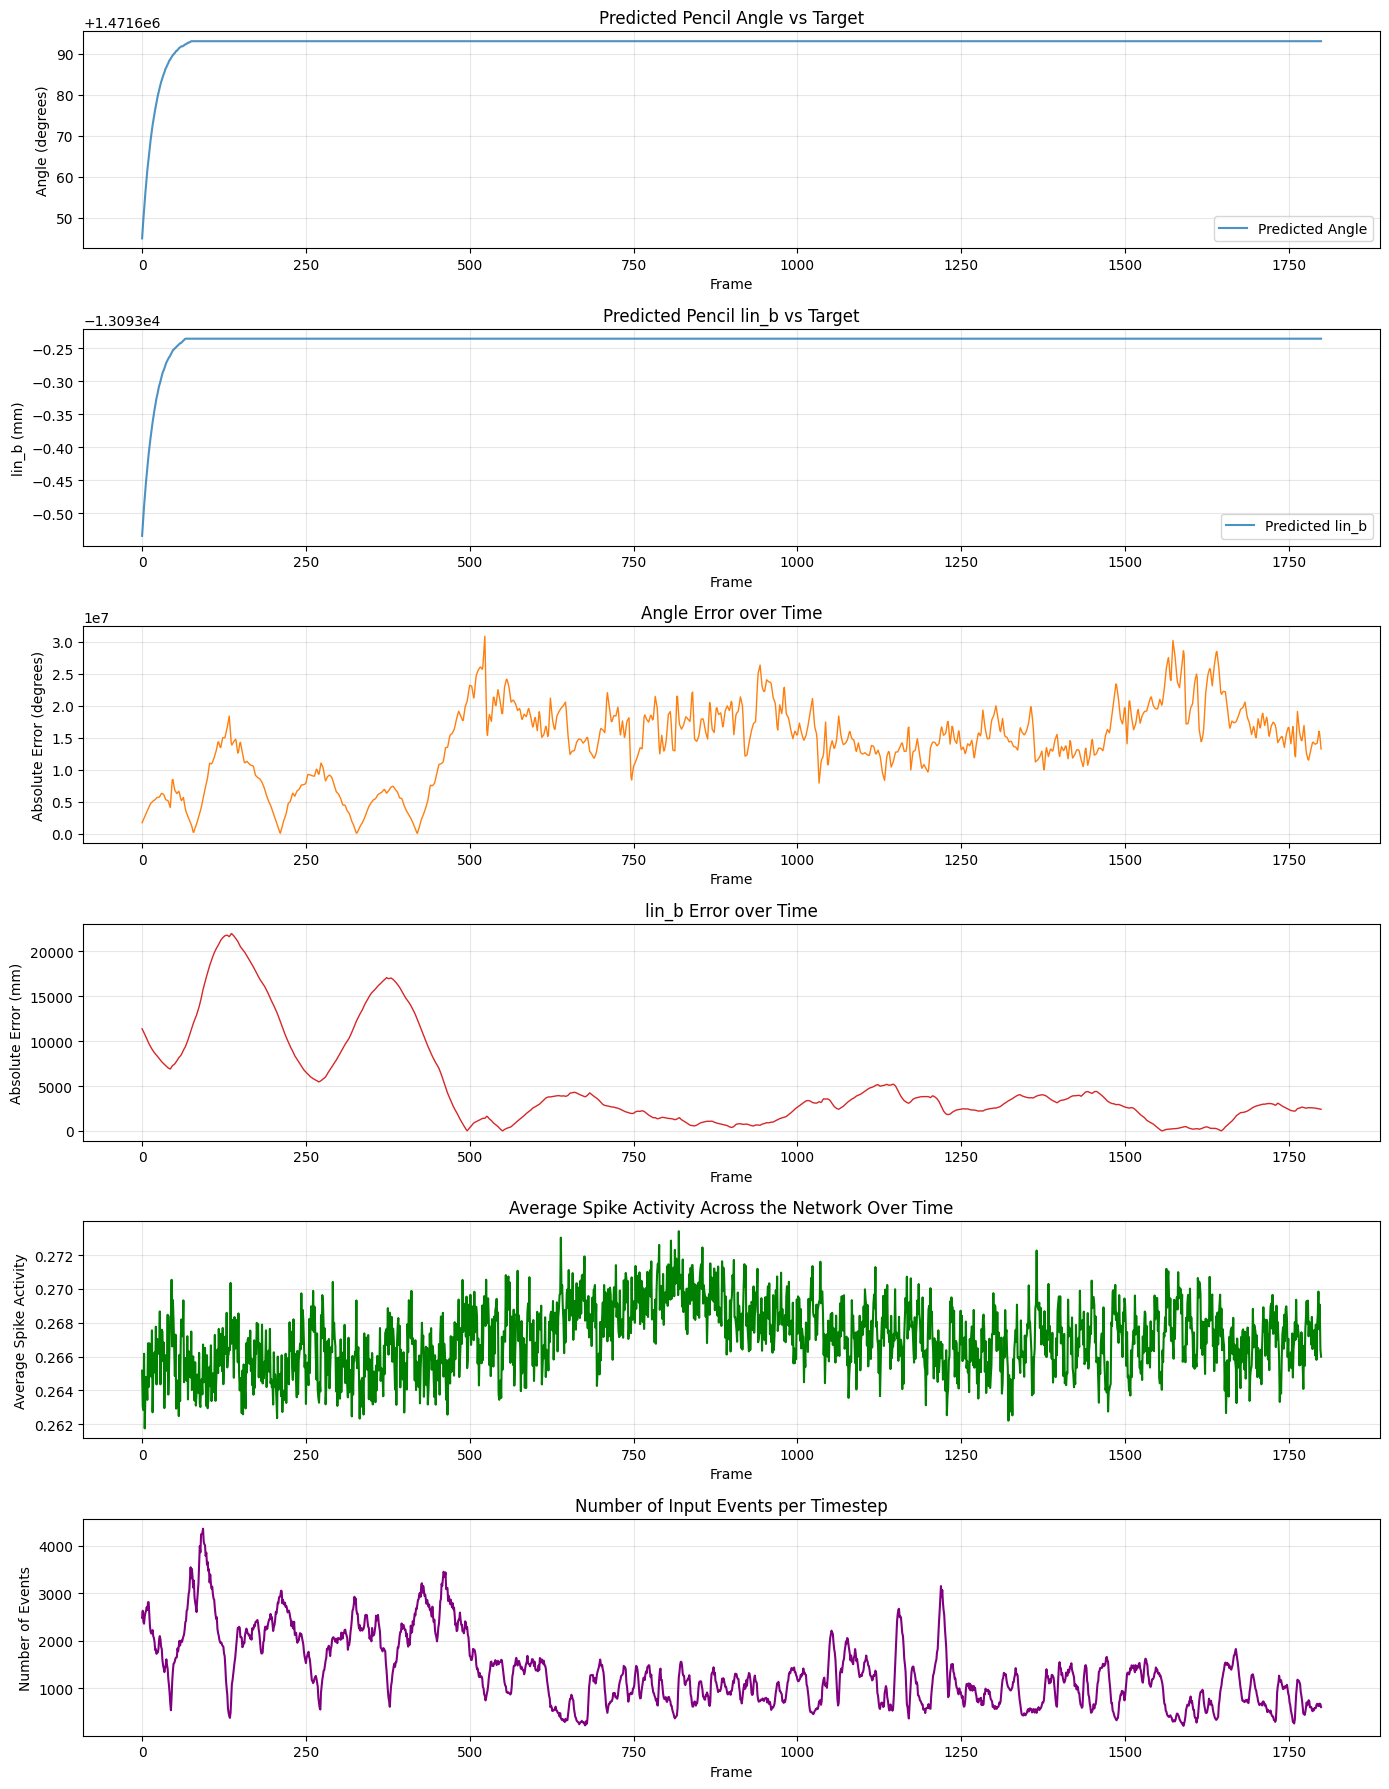


Error statistics (full sequence):
  Angle mean error: 14836294.00 deg
  Angle std error:  4797444.50 deg
  Angle max error:  30841888.00 deg
  lin_b mean error: 3894.53 mm
  lin_b std error:  3834.11 mm
  lin_b max error:  22058.02 mm

Error statistics (window):
  Angle mean error: 14159175.00 deg
  Angle std error:  5872334.00 deg
  Angle max error:  30841888.00 deg
  lin_b mean error: 4991.00 mm
  lin_b std error:  5193.38 mm
  lin_b max error:  21984.07 mm


In [41]:
# Continuous results visualization
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3 * n_plots))

window_start = 200
window_end = min(2000, len(test_mem_continuous))

output_window = denormalize_targets(test_mem_continuous[window_start:window_end])
target_window = denormalize_targets(test_target_continuous[window_start:window_end])
output_full = denormalize_targets(test_mem_continuous)
target_full = denormalize_targets(test_target_continuous)

angle_error_window = np.abs(output_window[:, ANGLE_INDEX] - target_window[:, ANGLE_INDEX])
position_error_window = np.abs(output_window[:, POSITION_INDEX] - target_window[:, POSITION_INDEX])
angle_error_full = np.abs(output_full[:, ANGLE_INDEX] - target_full[:, ANGLE_INDEX])
position_error_full = np.abs(output_full[:, POSITION_INDEX] - target_full[:, POSITION_INDEX])

axes[0].plot(output_window[:, ANGLE_INDEX], label="Predicted Angle", alpha=0.8, linewidth=1.5)
# axes[0].plot(target_window[:, ANGLE_INDEX], label="Target Angle", alpha=0.8, linewidth=1.5)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Angle (degrees)")
axes[0].set_title("Predicted Pencil Angle vs Target")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(output_window[:, POSITION_INDEX], label=f"Predicted {POSITION_NAME}", alpha=0.8, linewidth=1.5)
# axes[1].plot(target_window[:, POSITION_INDEX], label=f"Target {POSITION_NAME}", alpha=0.8, linewidth=1.5)
axes[1].set_xlabel("Frame")
axes[1].set_ylabel(f"{POSITION_NAME} ({POSITION_UNIT})")
axes[1].set_title(f"Predicted Pencil {POSITION_NAME} vs Target")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(angle_error_window, color='tab:orange', linewidth=1)
axes[2].set_xlabel("Frame")
axes[2].set_ylabel("Absolute Error (degrees)")
axes[2].set_title("Angle Error over Time")
axes[2].grid(True, alpha=0.3)

axes[3].plot(position_error_window, color='tab:red', linewidth=1)
axes[3].set_xlabel("Frame")
axes[3].set_ylabel(f"Absolute Error ({POSITION_UNIT})")
axes[3].set_title(f"{POSITION_NAME} Error over Time")
axes[3].grid(True, alpha=0.3)

if monitor_mode in ["spikes", "both"]:
    axes[4].plot(spike_activity_total[window_start:window_end], color='green', linewidth=1.5)
    axes[4].set_xlabel("Frame")
    axes[4].set_ylabel("Average Spike Activity")
    axes[4].set_title("Average Spike Activity Across the Network Over Time")
    axes[4].grid(True, alpha=0.3)

    axes[5].plot(num_events_per_timestep[window_start:window_end], color='purple', linewidth=1.5)
    axes[5].set_xlabel("Frame")
    axes[5].set_ylabel("Number of Events")
    axes[5].set_title("Number of Input Events per Timestep")
    axes[5].grid(True, alpha=0.3)

    print("\nSpike activity statistics (average over time):")
    for layer_name in all_layers:
        mean_spike = np.mean(spike_activity_over_time[layer_name])
        print(f"  {layer_name:20s}: {mean_spike:.4f}")

    print(f"\nAverage spike activity across the entire network: {np.mean(spike_activity_total):.4f}")

plt.tight_layout()
plt.show()

print("\nError statistics (full sequence):")
print(f"  Angle mean error: {np.mean(angle_error_full):.2f} deg")
print(f"  Angle std error:  {np.std(angle_error_full):.2f} deg")
print(f"  Angle max error:  {np.max(angle_error_full):.2f} deg")
print(f"  {POSITION_NAME} mean error: {np.mean(position_error_full):.2f} {POSITION_UNIT}")
print(f"  {POSITION_NAME} std error:  {np.std(position_error_full):.2f} {POSITION_UNIT}")
print(f"  {POSITION_NAME} max error:  {np.max(position_error_full):.2f} {POSITION_UNIT}")

print("\nError statistics (window):")
print(f"  Angle mean error: {np.mean(angle_error_window):.2f} deg")
print(f"  Angle std error:  {np.std(angle_error_window):.2f} deg")
print(f"  Angle max error:  {np.max(angle_error_window):.2f} deg")
print(f"  {POSITION_NAME} mean error: {np.mean(position_error_window):.2f} {POSITION_UNIT}")
print(f"  {POSITION_NAME} std error:  {np.std(position_error_window):.2f} {POSITION_UNIT}")
print(f"  {POSITION_NAME} max error:  {np.max(position_error_window):.2f} {POSITION_UNIT}")

### Normalization Statistics Analysis

Analyzes how normalization layers transform activations over time.

In [32]:
def plot_norm_activity_over_time(norm_activity_over_time, layer_name):
    """Visualize how normalization statistics evolve over time."""
    activity = norm_activity_over_time[layer_name]
    timesteps = np.arange(len(activity['input_mean']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Activity Over Time: {layer_name}', fontsize=16)

    # Plot 1: Mean evolution
    ax = axes[0, 0]
    ax.plot(timesteps, activity['input_mean'], '-', label='Input Mean', alpha=0.7, linewidth=2)
    ax.plot(timesteps, activity['output_mean'], '-', label='Output Mean', alpha=0.7, linewidth=2)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Mean')
    ax.set_title('Mean Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Std evolution
    ax = axes[0, 1]
    ax.plot(timesteps, activity['input_std'], '-', label='Input Std', alpha=0.7, linewidth=2)
    ax.plot(timesteps, activity['output_std'], '-', label='Output Std', alpha=0.7, linewidth=2)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Std')
    ax.set_title('Std Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: Range evolution
    ax = axes[1, 0]
    ax.plot(timesteps, activity['input_range'], '-', label='Input Range', alpha=0.7, linewidth=2)
    ax.plot(timesteps, activity['output_range'], '-', label='Output Range', alpha=0.7, linewidth=2)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Range (max - min)')
    ax.set_title('Value Range Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 4: Actual scaling factor (output / input)
    ax = axes[1, 1]

    # Compute scaling factors
    std_scaling = np.array(activity['output_std']) / (np.array(activity['input_std']) + 1e-8)
    range_scaling = np.array(activity['output_range']) / (np.array(activity['input_range']) + 1e-8)

    ax.plot(timesteps, std_scaling, '-', alpha=0.7, linewidth=2,
            label='Std Scaling (out/in)', color='purple')
    ax.plot(timesteps, range_scaling, '-', alpha=0.7, linewidth=2,
            label='Range Scaling (out/in)', color='orange')
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='No scaling (1x)')

    # Add average line
    avg_std_scaling = np.mean(std_scaling)
    ax.axhline(y=avg_std_scaling, color='purple', linestyle=':', alpha=0.7, linewidth=2,
               label=f'Avg Std Scaling: {avg_std_scaling:.1f}x')

    ax.set_xlabel('Timestep')
    ax.set_ylabel('Scaling Factor (Output / Input)')
    ax.set_title('Amplification Factor Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)  # Ensure it starts from 0

    plt.tight_layout()
    return fig

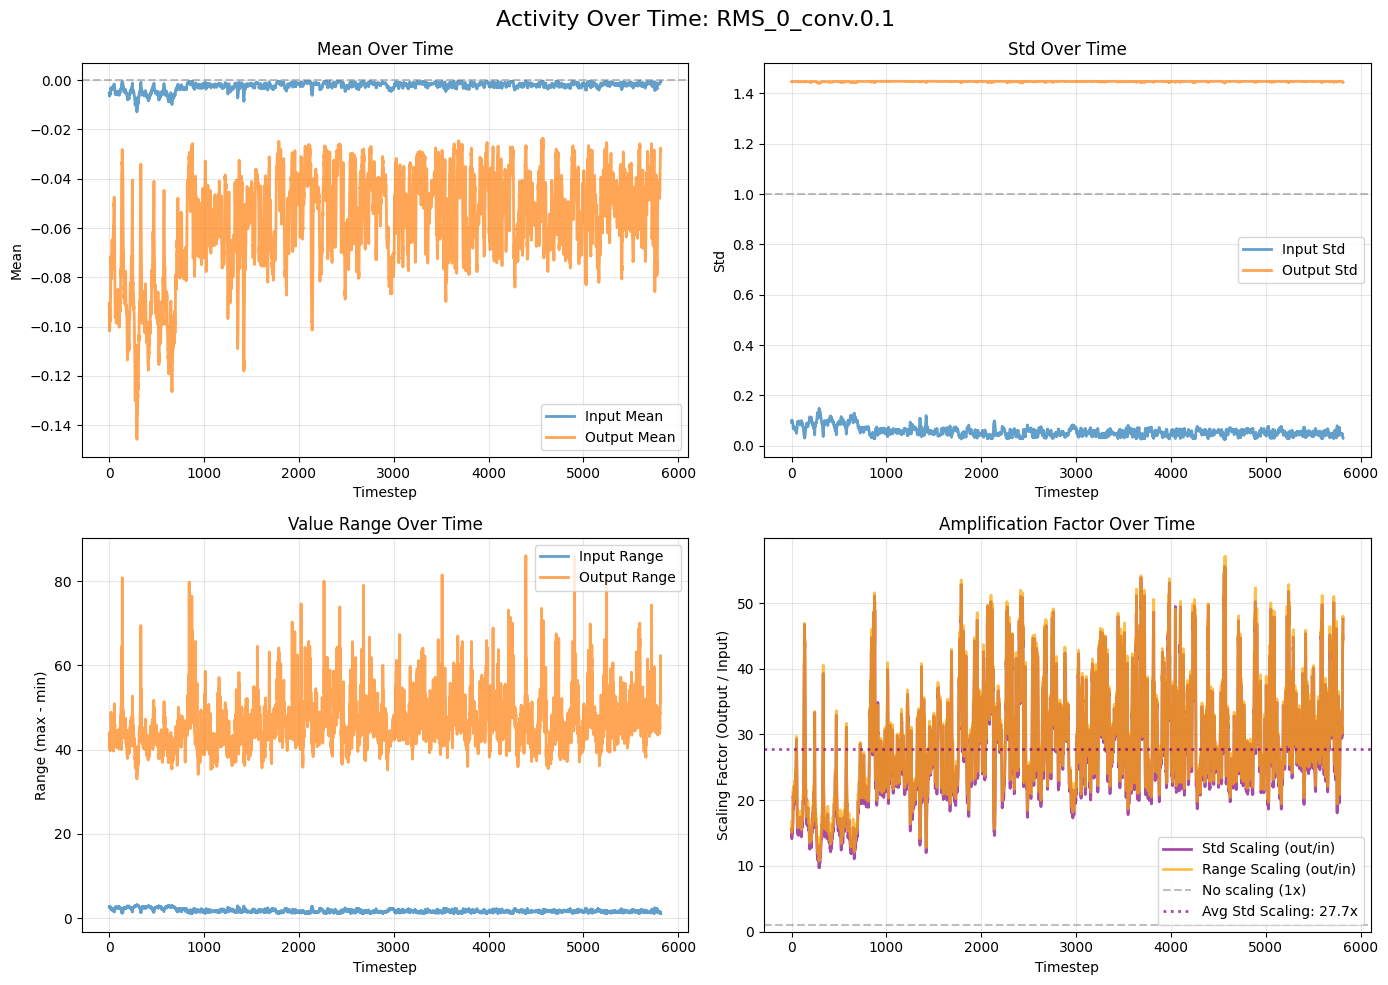

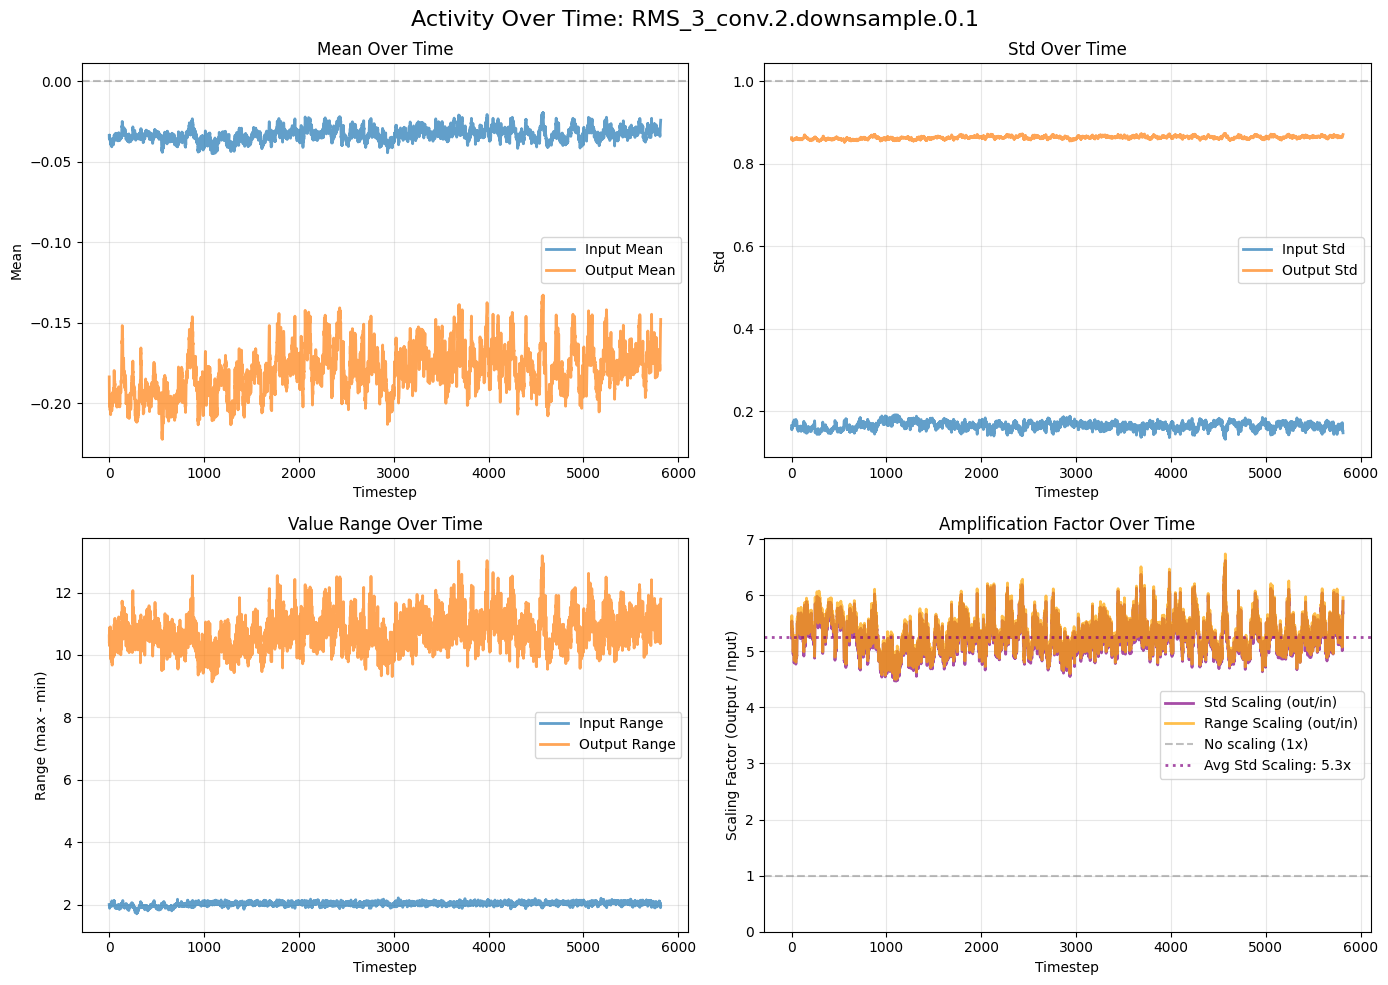

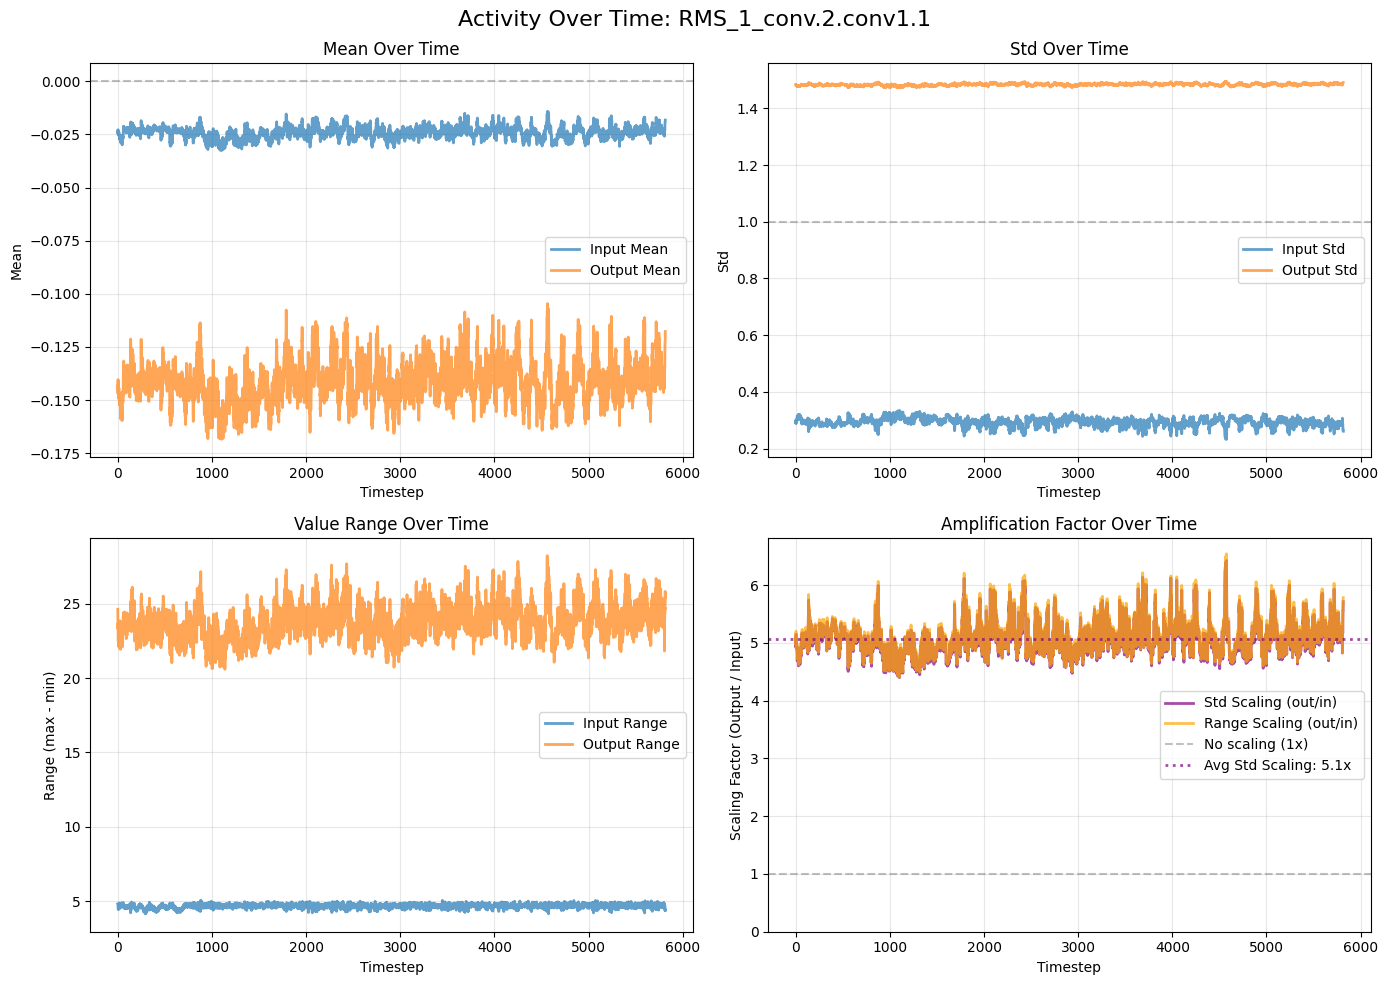

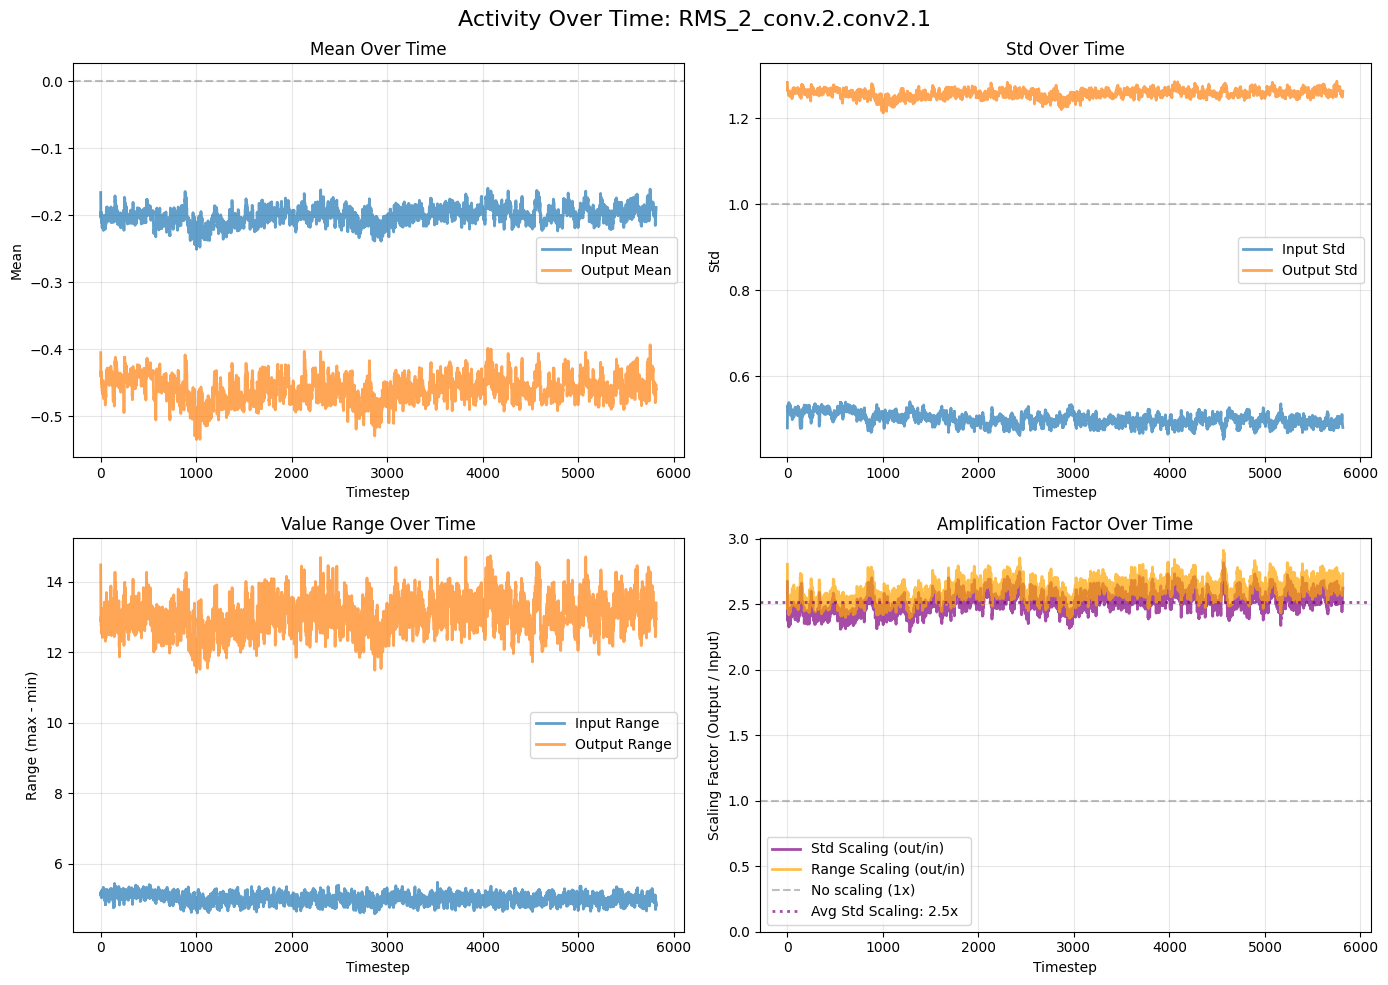

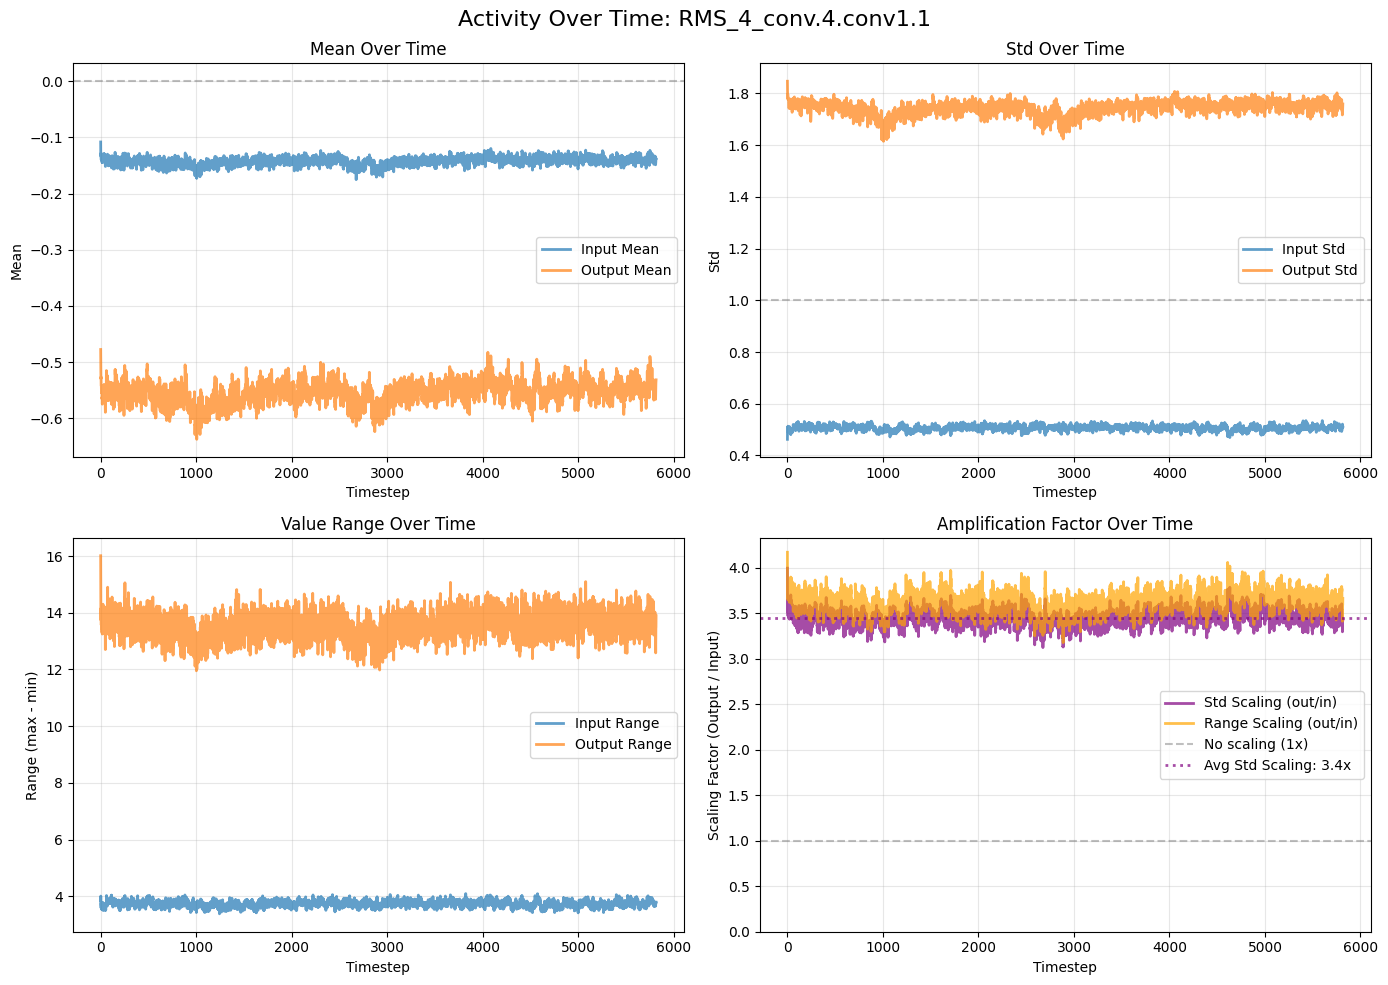

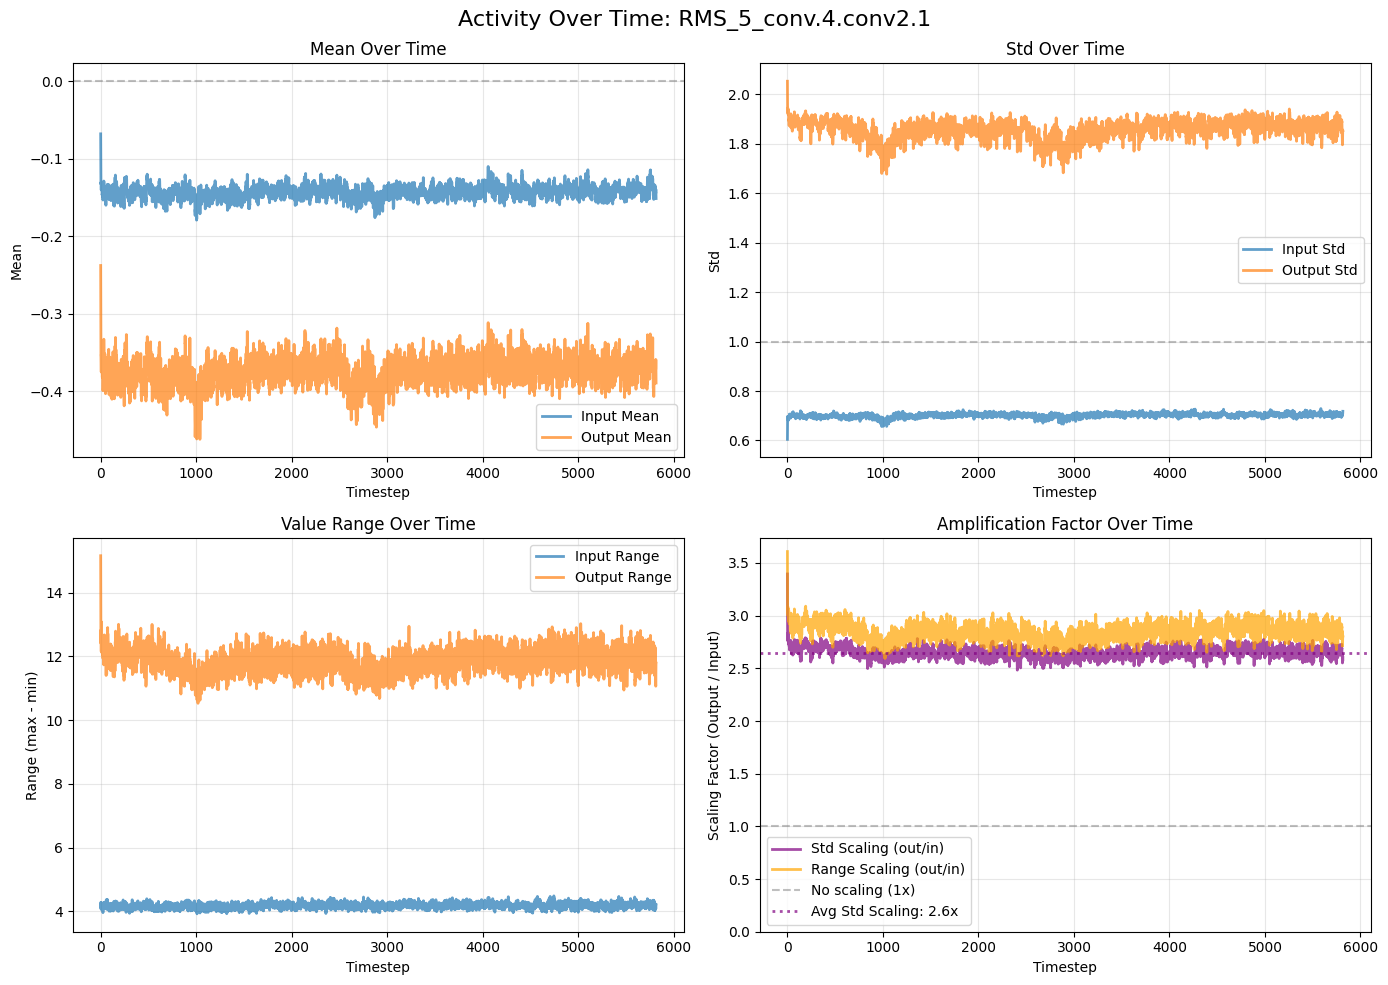

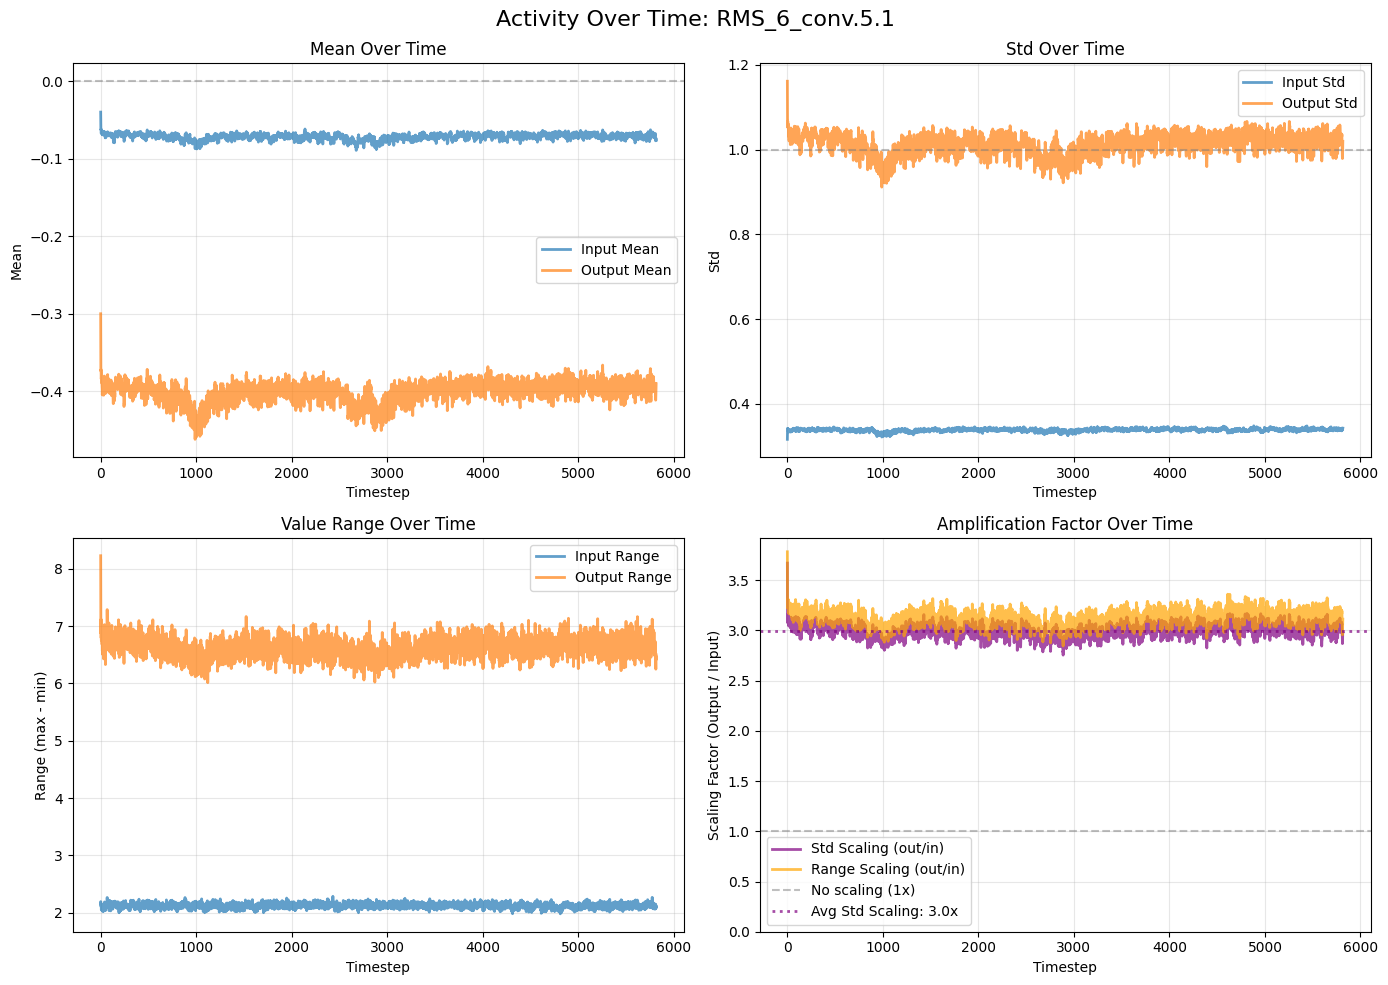

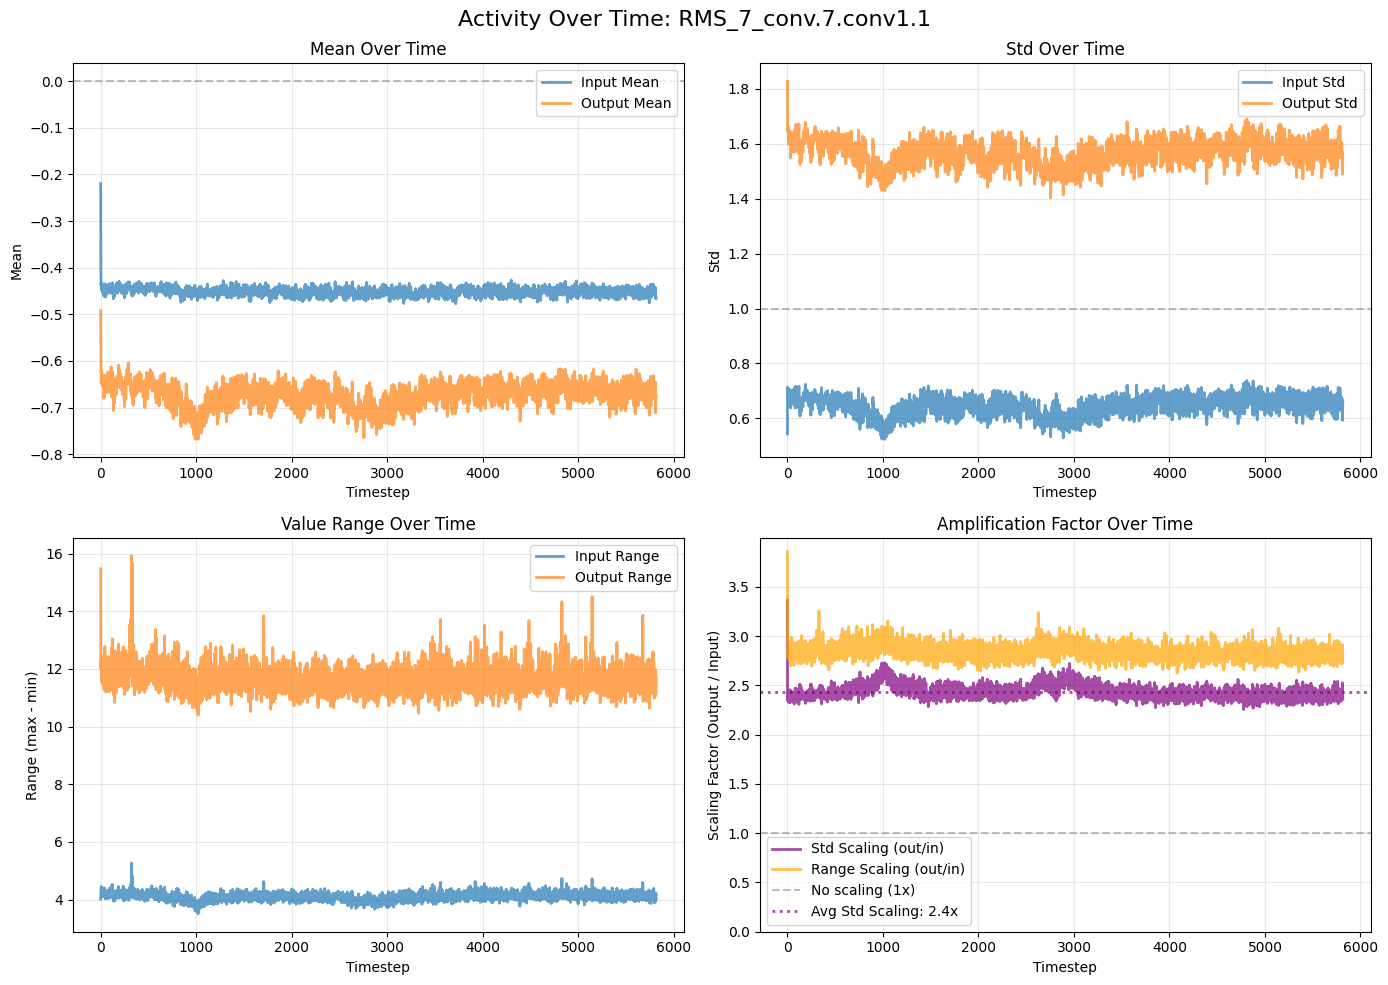

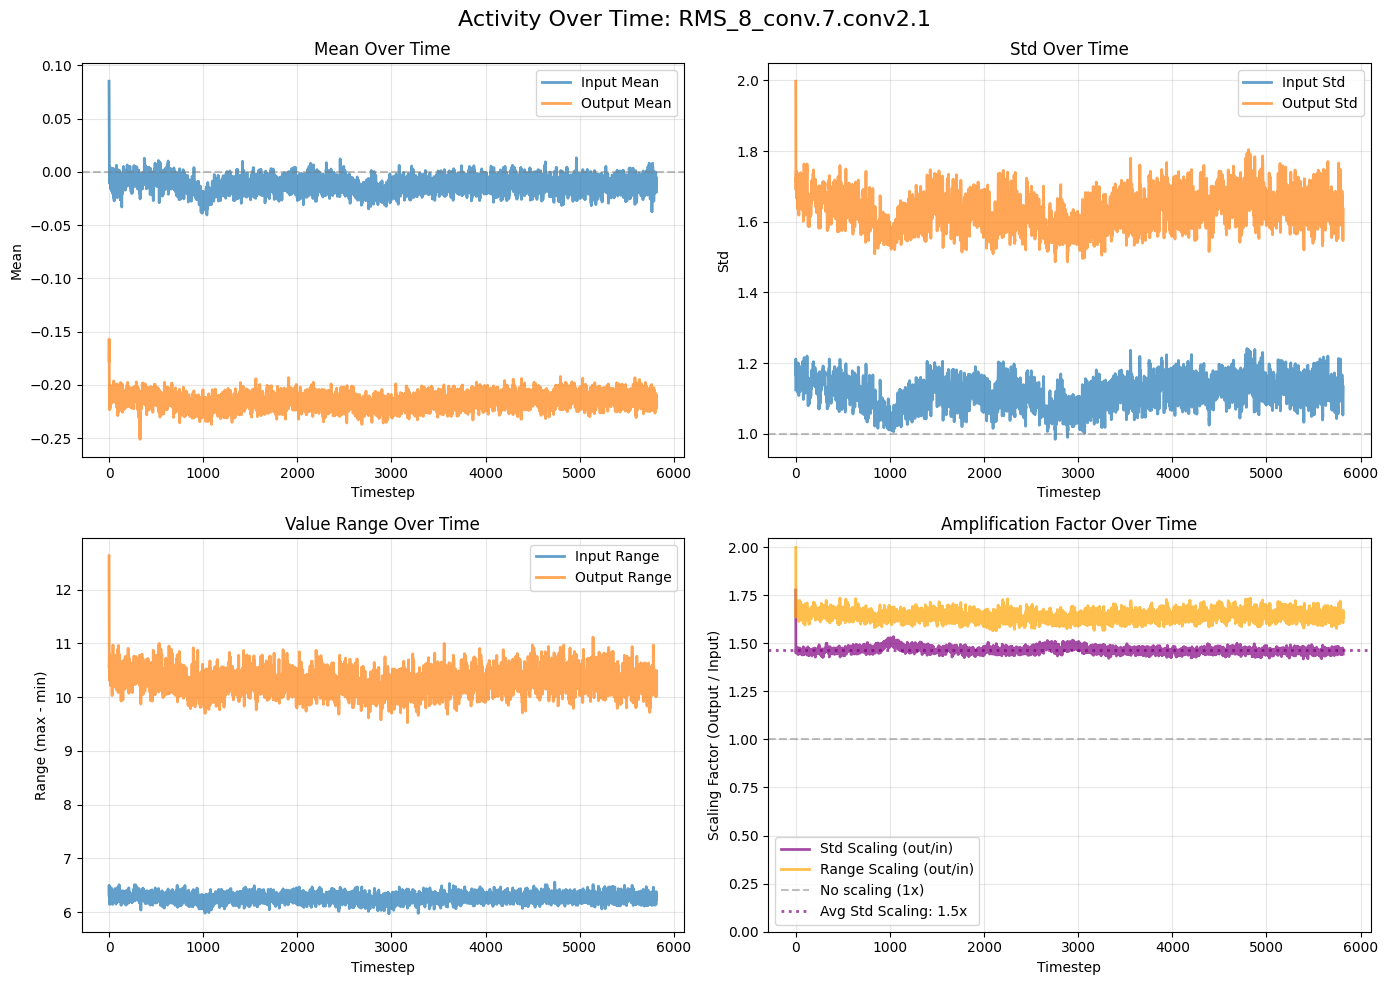

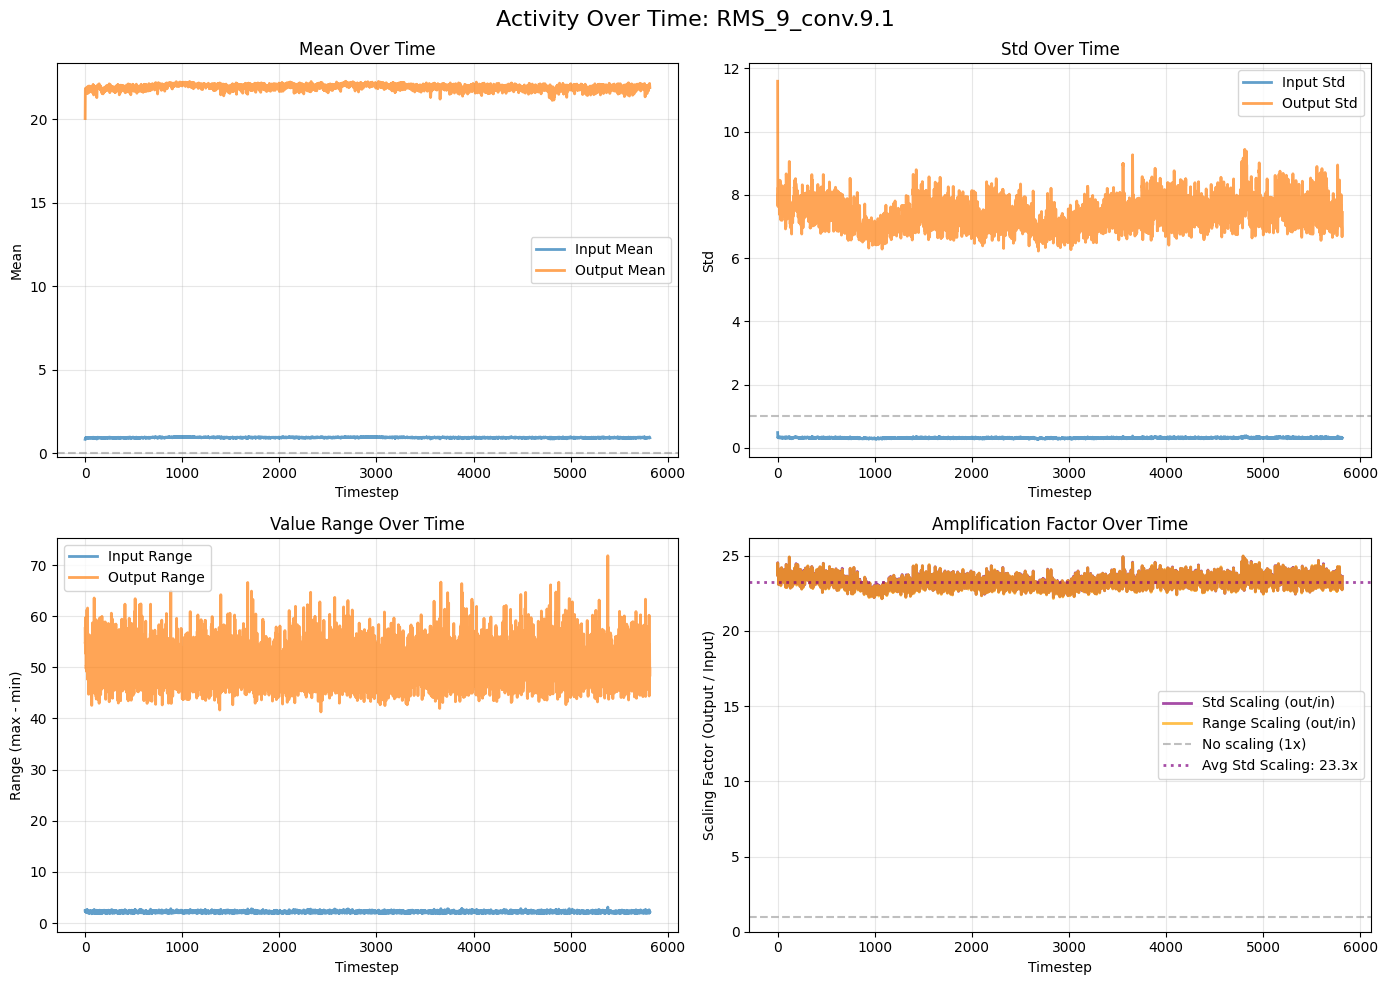

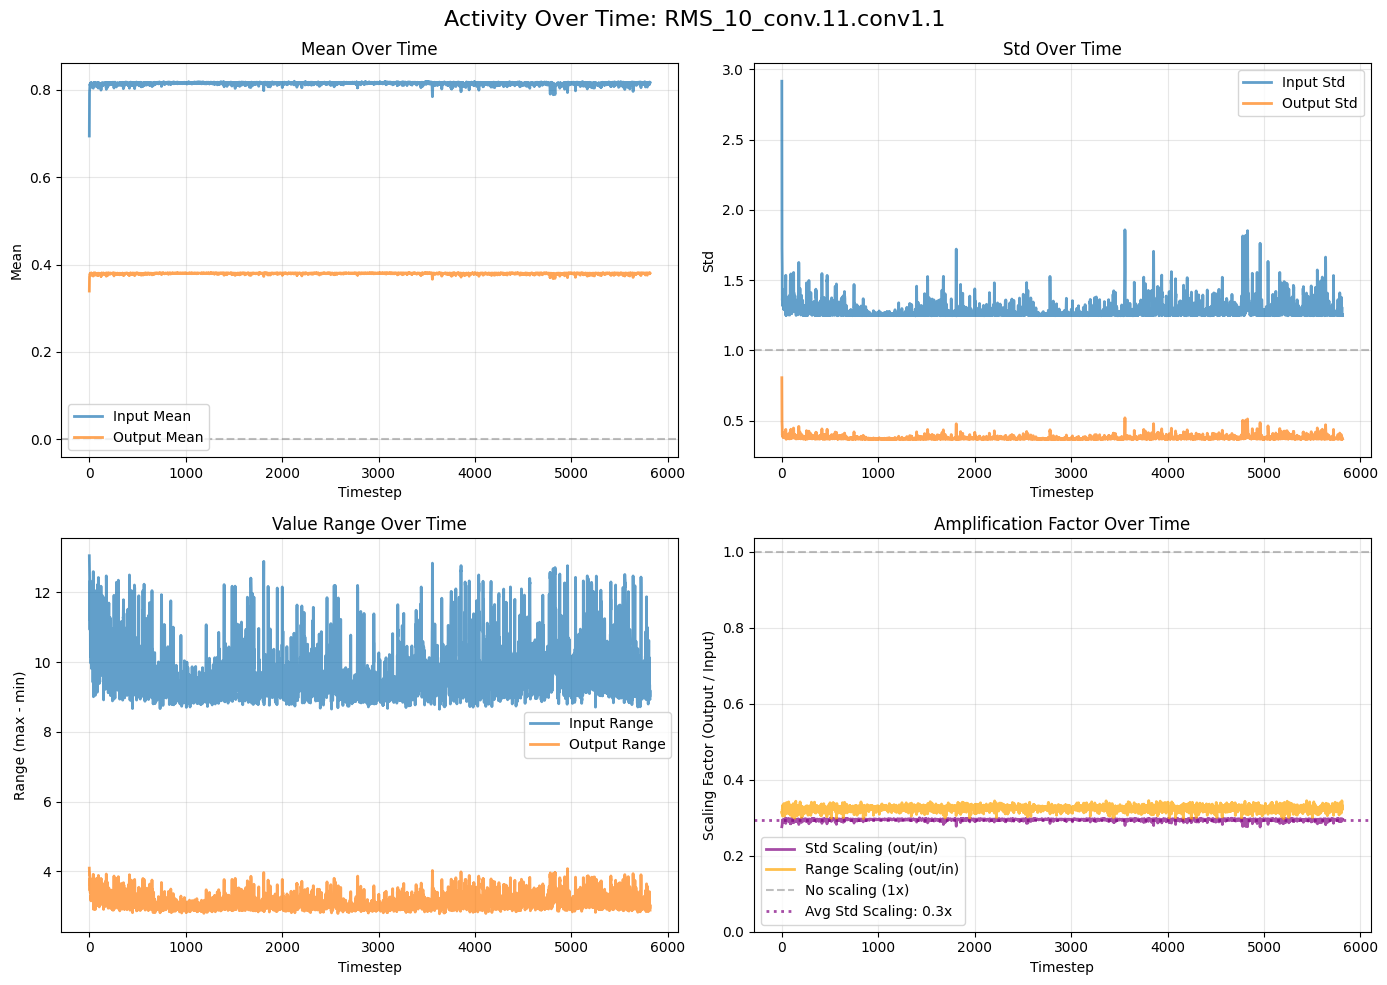

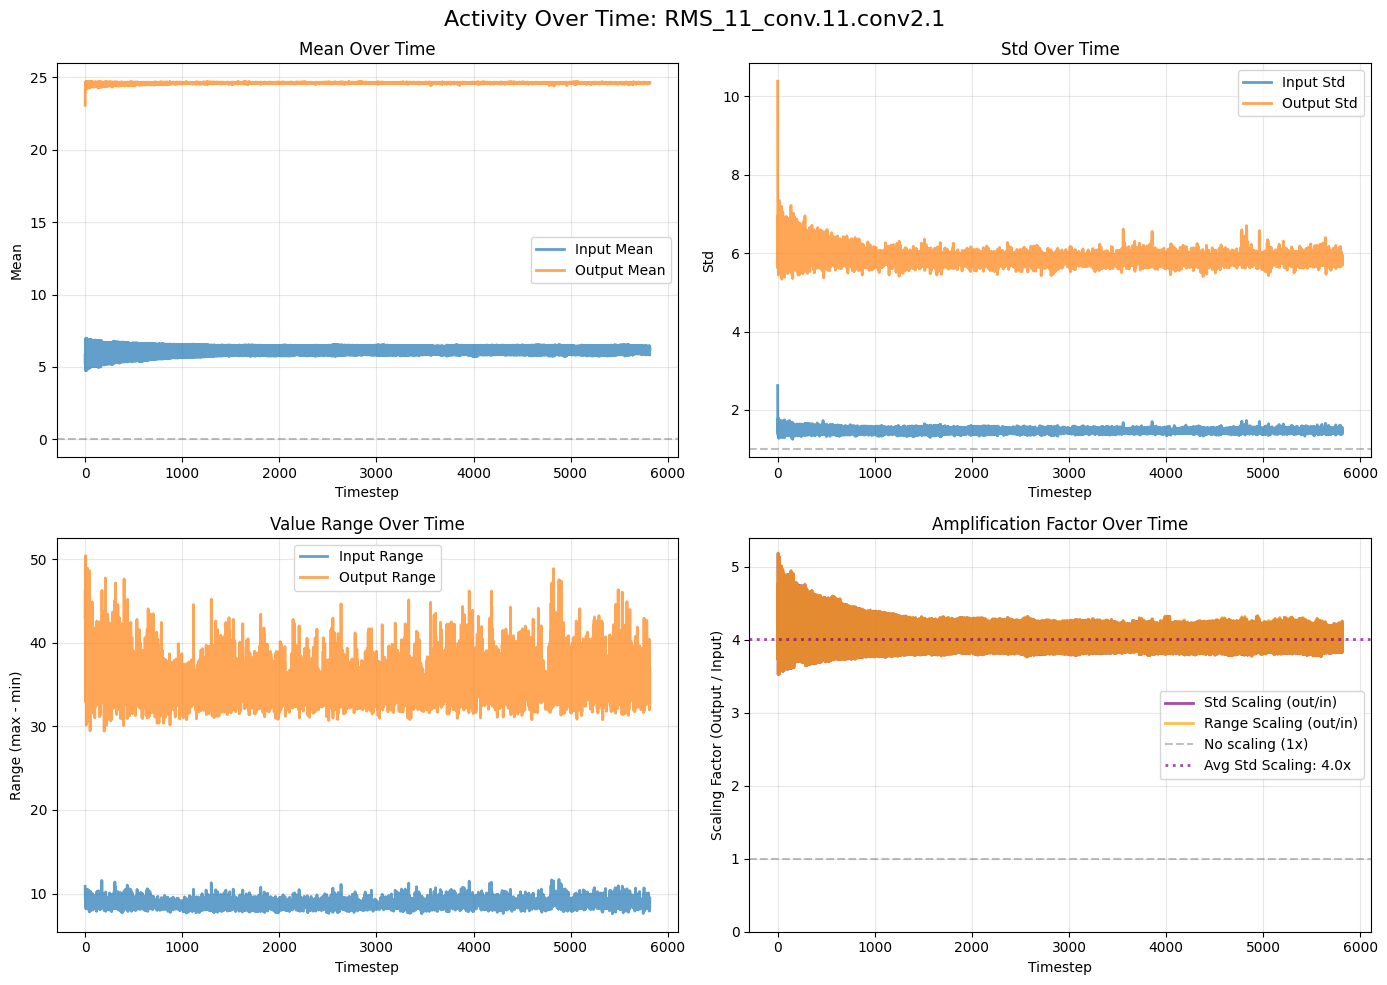

In [33]:
if monitor_mode in ["norm", "both"]:
    # Visualize for each layer
    for layer_name in norm_activity_over_time.keys():
        fig = plot_norm_activity_over_time(norm_activity_over_time, layer_name)
        plt.show()
        # Or save: fig.savefig(f'{layer_name}_temporal_analysis.png')

In [34]:
def compute_mean_amplification_per_layer(norm_activity_over_time):
    """Compute average amplification factor (std_out / std_in) over time for each layer."""
    layer_names = []
    mean_amplifications = []

    for layer_name, activity in norm_activity_over_time.items():
        input_std = np.array(activity['input_std'])
        output_std = np.array(activity['output_std'])

        std_scaling = output_std / (input_std + 1e-8)
        mean_scaling = std_scaling.mean()

        layer_names.append(layer_name)
        mean_amplifications.append(mean_scaling)

    return layer_names, np.array(mean_amplifications)

def plot_network_amplification(layer_names, mean_amplifications):
    """Bar plot showing average amplification factor per layer."""
    layers = np.arange(len(layer_names))

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(layers, mean_amplifications, alpha=0.8, color='purple')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='No scaling (1x)')

    avg_network = mean_amplifications.mean()
    ax.axhline(avg_network, color='black', linestyle=':', linewidth=2,
               label=f'Network avg = {avg_network:.1f}x')

    ax.set_xlabel('Layer')
    ax.set_ylabel('Mean Amplification (Output / Input)')
    ax.set_title(f'Mean Amplification Factor per Layer (avg={avg_network:.1f}x)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

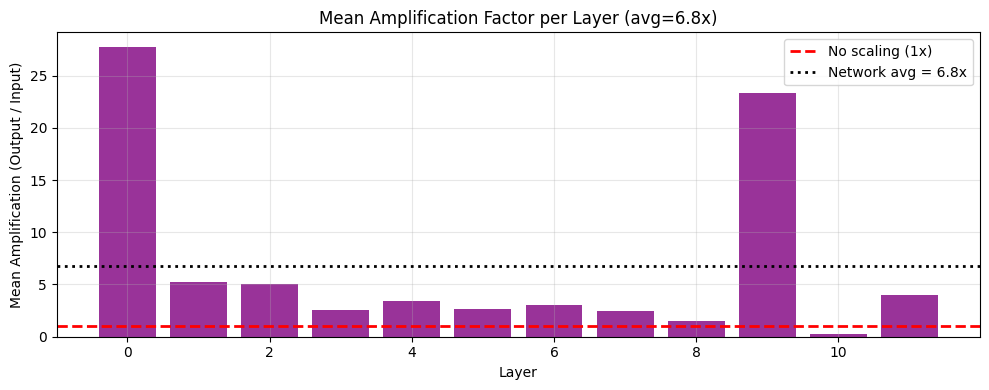

In [35]:
if monitor_mode in ["norm", "both"]:
    layer_names, mean_amplifications = compute_mean_amplification_per_layer(
        norm_activity_over_time
    )

    fig = plot_network_amplification(layer_names, mean_amplifications)
    plt.show()


In [36]:
if use_wandb:
    wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/number,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/train_loss,██▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▃▄▃▃▃▂▂▂▂▂▂▁
epoch/val_loss_l1,███▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
epoch/val_loss_mse,██▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
epoch/val_rel_err,▃▃█▂▄▂▂▂▄▁▃▅▄▂▁▂▂▁▂▄▃▂▂▂▄▁▃▄▁▂
train/batch,█▆▆▄▅▇▅▅█▅▇▄▇▃▇▄▆█▆▂▄█▄▁▆▂▇▂▄▅▅▇▄█▇▂▃▃▂█
train/chunk_loss,▂▃▅▄▁▃▂▁▄▄▄▅█▅▄▃▂▃▃▂▄▆▂▂▂▂▃▂▃▁▁▁▃▄▃▄▄▃▂▃
train/epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,30
